In [2]:
#### Added in HW 3 ####
#### A procedure to create bootstrap datasets by sampling (with replacement) from the current training set ####

import numpy as np

def bootstrap_dataset(X, y):

    number_of_records = X.shape[0] #### Gets the total number of instances in dataset ####
    #### X.shape returns a tuple (instances, attributes) of a dataset e.g (569, 30) for WDBC ####
    #### shape[0] is number of instances ####
    #### shape[1] is number of features/attributes ####

    records = np.random.choice(number_of_records, size = number_of_records, replace = True, p = None)
    #### random.choice(a, size=None, replace=True, p=None)
    #### Parameters : a : 1-D array-like or int, - If an ndarray, a random sample is generated from its elements
    #### size = int or tuple of ints, optional, - Output shape. eg if value is 5, then 5 samples are drawn
    #### replace : boolean, optional, - Whether the sample is with or without replacement. Default is True, meaning that a value of a can be selected multiple times
    #### p : 1-D array-like, optional, - The probabilities associated with each entry in a


    #### X[records] uses the sampled indices to select features or instances from X ####
    #### y[records] uses the sampled indices to select labels from y ####
    #### Both are returned together to keep features and labels in sync
    return X[records], y[records]

In [4]:
#### Added in HW 3 ####
#### a majority voting mechanism that takes into account the predictions made by each tree
#### in the ensemble to classify new instances

from collections import Counter

def majority_vote(predictions):    
    vote_counts = Counter(predictions)  
    #### predictions is a list of predictions from all trees ####
    #### A Counter is a dict subclass for counting hashable objects. 
    #### It is a collection where elements are stored as dictionary keys and their counts are stored as dictionary values. 
    
    #### most_common(n) - Return a list of the n most common elements and their counts from the most common to the least e.g. [('malignant', 3), ('benign', 2)]
    #### [0] picks the first tuple in the list e.g. (malignant, 3)
    #### [0][0] picks the first element from the tuple e.g. 'malignant'
    return vote_counts.most_common(1)[0][0]

In [6]:
#### Added in HW 3 ####
def create_stratified_folds(X, y, k=5):

    labels = np.unique(y)
    #### np.unique(y) - returns the unique labels from the dataset
    #### get all unique class labels e.g. for WDBC dataset it returns ['Benign', 'Malignant']

    folds = [[] for i in range(k)]
    #### create k empty lists e.g. [[], [], [], [], []]

    for label in labels:
        #### handle each label values separately to keep proportions

        label_indices = np.where(y == label)[0]
        #### y == label compares every value in y with the label value and returns True/False for every value of y             
        #### np.where finds positions where condition is True and returns a tuple containing a numpy array e.g. (array([0, 2, 3]),)
        #### [0] returns the numpy array from the tuple e.g. array([0, 2, 3])

        np.random.shuffle(label_indices)
        #### np.random.shuffle(label_indices) randomly shuffles the order of the values in the label_indices array
        #### the original array values will be randomly reshuffled and presented in a different order in the array
        #### array([1,2,3,4]) will be reshuffled to array([3,2,4,1])


        for i, index in enumerate(label_indices):
        #### enumerate returns both the position number (i) and label_indices values (index)
        #### i = position number e.g. 0, 1, 2, 3, 4,...
        #### index = row numbers in label indices values e.g. 3, 2, 4, 1, ...
            folds[i % k].append(index)
            #### i % k provides the remainder values of dividing the position number with k = 5 (no of folds) e.g (i % k) is 0, 1, 2, 3, 4
            #### folds[i % k] assigns each remainder values to each different folds e.g fold 0, fold 1, fold 2, fold 3, fold 4
            #### folds[i % k].append(index) adds the row numbers from label indices to each fold

    #### returns k folds as a list of k lists ####
    #### each fold contains row numbers of instances assigned to that fold
    return folds

In [8]:
#### From HomeWork 1 ####

import numpy as np

def entropy(column_name):
# definition for entropy calculation, the parameter used is the column name
    
    counts = column_name.value_counts(normalize = True) 
    # value_counts = returns the count of each of the unique values in the series
    # normalize = If True, returns the counts as a percentage of the total rather than the actual counts

    entropy = 0

    for count in counts:
        entropy -= (count * np.log2(count))

    return entropy

In [10]:
#### From HomeWork 1 ####
#### UPDATED IN HW 3 ####

def average_entropy(dataframe, feature, column_name = "class"):

    TOTAL = len(dataframe)  # len() = Return the length (the number of items) of an object.
    AVG_entropy = 0

    #### UPDATED IN HW 3 - Included average entropy calculation logic for numerical attributes ####
    if '_num' in feature:
        #### check if the feature is a numerical attributes ####
        threshold = dataframe[feature].mean()
        
        #### calculate the mean of the numerical feature values in the dataframe
        
        left  = dataframe[dataframe[feature] <= threshold]
        #### left subset : instances where feature values <= threshold
        right = dataframe[dataframe[feature] >  threshold]
        #### right subset : instances where feature values > threshold

        for subset in [left, right]:
            #### loops through both left and right subsets ####
            if len(subset) == 0:
                #### if subset is empty skip it ####
                continue
            weight = len(subset) / TOTAL  # Computes |D_j| / |D| = proportion of instances in partition D_j after splitting on threshold mean value

            subset_entropy = entropy(subset[column_name]) # Computes the entropy of the subset corresponding to a specific value of the selected attribute
            
            AVG_entropy += weight * subset_entropy # Accumulates |D_j| / |D| * I(D_j) to compute Info_A(D), the average entropy after splitting on attribute A

    else:
        
        for value in dataframe[feature].unique():
        # unique() = Returns the unique value in selected column

            subset = dataframe[dataframe[feature] == value]

            weight = len(subset) / TOTAL  # Computes |D_j| / |D| = proportion of instances in partition D_j after splitting on attribute A
        
            subset_entropy = entropy(subset[column_name]) # Computes the entropy of the subset corresponding to a specific value of the selected attribute

        #print(value, weight, subset_entropy)

            AVG_entropy += weight * subset_entropy
        # Accumulates |D_j| / |D| * I(D_j) to compute Info_A(D), the average entropy after splitting on attribute A

    return AVG_entropy

In [12]:
#### From HomeWork 1 ####

def information_gain(dataframe,column_name,feature):

    Entropy_of_Dataset = entropy(dataframe[column_name])
    Average_Entropy_of_Partition = average_entropy(dataframe, feature)

    Information_Gain = (Entropy_of_Dataset - Average_Entropy_of_Partition)

    return Information_Gain

In [14]:
#### From HomeWork 1 ####

def best_feature(dataframe, column_name, features):
    if not features:
        return None
        
    Info_Gain = {}  # Initialize an empty dictionary to store Information Gain values
   
    for attribute in features:
        Info_Gain[attribute] = information_gain(dataframe, column_name, attribute) 
        # Compute Information Gain for the current attribute and store it in the dictionary using the attribute name as the key
        
        # print("Information Gain for", attribute, "is", Info_Gain[attribute])

    if not Info_Gain:
        return None
        
    Best_Feature = pd.Series(Info_Gain).sort_values(ascending=False).index[0]
    # pd.Series = Convert dictionary to pandas Series, sort features by Information Gain in descending order,
    # and select the feature with the highest Information Gain
    # print(Best_Feature)
    return Best_Feature

In [16]:
#### From HomeWork 1 ####

# Function used to return the majority class label in the dataframe target column
def majority_class(dataframe, column_name):
    counts = dataframe[column_name].value_counts()
    majority = counts.sort_values(ascending=False).index[0]
    
    return majority

In [18]:
#### From HomeWork 1 ####
#### UPDATED IN HW 3 ####

import random
import math

#### UPDATED IN HW 3 - Added new parameters - maximum_depth, minimum_size_for_split, depth
def build_tree(dataframe, column_name, features, maximum_depth = 10, minimum_size_for_split = 5, depth = 0):
    #### maximum_depth : stop splitting whenever the current branch of the tree becomes too deep, 
    #### that is, when its depth exceeds some pre-defined value that you select empirically
    
    #### minimum_size_for_split : stop splitting nodes whenever the data partition associated with the current node contains fewer than n instances, 
    #### for some value of n that you choose empirically

    #### depth : tracks the current depth of the tree 
    #### initial value is set to 0 and increases by 1 for each split

    # If all instances in belong to the same class, Define node as a leaf node labeled with y and return it
    if dataframe[column_name].nunique() == 1:  # nunique() - returns the number of unique values in a column
        return {"is_leaf": True, "label": dataframe[column_name].iloc[0]}

    #### UPDATED in HW 3 - Not needed for random forest ####
    #  If there are no more attributes that can be tested, Define node as a leaf node labeled with the majority class in , and return it
    #### if len(features) == 0:
        #### return {"is_leaf": True, "label": majority_class(dataframe, column_name)}

    #### UPDATED IN HW 3 ####
    if depth >= maximum_depth:
        #### depth starts from 0 and increases by 1 after each split
        #### maximum_depth : stop splitting whenever the current branch of the tree becomes too deep, 
        #### that is, when its depth exceeds some pre-defined value

        #### makes the current node a leaf node
        #### majority_class picks the most common label from the current node dataframe
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}


    #### UPDATED IN HW 3 ####
    if len(dataframe) < minimum_size_for_split:
        #### minimum_size_for_split : stop splitting nodes whenever the data partition associated with the current node contains fewer than n instances, 
        #### for some value of n that you choose empirically

        #### makes the current node a leaf node
        #### majority_class picks the most common label from the current node dataframe        
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
    
    node_majority = majority_class(dataframe, column_name)
    
    #### UPDATED IN HW 3 ####
    m_attributes = round(math.sqrt(len(features))) 
    selected_features = random.sample(features, m_attributes)

    best = best_feature(dataframe, column_name, selected_features)

    #### UPDATED IN HW 3 ####
    if best is None or information_gain(dataframe, column_name, best) <= 0.01:
        #### stopping criteria ####
        #### when the best feature is none - no feature found ####
        #### when the information_gain <= 0.01 - split not useful ####
        
        #### makes the current node a leaf node ####
        #### majority_class picks the most common label from the current node dataframe  ####
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
    
    #### UPDATED IN HW3 - calculate threshold for numerical features ####
    if '_num' in best:
        threshold = dataframe[best].mean()
        #### if feature is numerical calculate mean as threshold ####
    else:
        threshold = None
        #### if feature is categorical set threshold to None ####
    
    node = {
        "is_leaf": False,
        "feature": best,
        "children": {},
        "majority": node_majority,
        "threshold" : threshold
        #### store threshold in node for use in predict_one() ####
    }
    # Outer dictionary creates the decision node using the best feature,
    # inner empty dictionary will store the branches (subtrees) for each feature value

    
    #### UPDATED in HW 3 - Not needed for random forest ####
    #### remaining_features = features.copy()  #  copy() - returns a shallow copy of the object
    #### remaining_features.remove(best)

    #### UPDATED in HW 3 : Logic for Numerical features ####
    if '_num' in best:
        #### if numerical feature is chosen as the best feature - feature with highest information gain ####
        left  = dataframe[dataframe[best] <= threshold]
        #### left subset: instances where feature value <= threshold ####
        right = dataframe[dataframe[best] >  threshold]
        #### right subset : instances where feature value > threshold ####


        if len(left) == 0 or len(right) == 0:
            #### if split creates empty subset — no useful split ####
            #### make current node a leaf node ####
            return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
               

        for split_name, subset in [('left', left), ('right', right)]:
            #### loops through 2 tuples ('left', left), ('right', right) ####
            #### split name is the name of the branch - 'left' and 'right' ####
            if len(subset) == 0:
                node["children"][split_name] = {"is_leaf": True, "label": node_majority}
                #### if the subset has no instances, then its assigned as leaf node and assigned the majority class as label
            else:
                node["children"][split_name] = build_tree(subset, column_name, features, maximum_depth = maximum_depth,
                                                          minimum_size_for_split = minimum_size_for_split, depth=depth+1)
                #### continue building subtree for this branch ####
    
    else:
        for value in dataframe[best].unique():
            subset = dataframe[dataframe[best] == value]

            #### UPDATED IN HW 3 ####
            if len(subset) == 0:
                node["children"][value] = {"is_leaf": True, "label": node_majority}
            else:
                node["children"][value] = build_tree(subset, column_name, features, maximum_depth = maximum_depth, 
                                                 minimum_size_for_split = minimum_size_for_split, depth = depth+1)
                #### maximum_depth = chosen value passed for next node split
                #### minimum_size_for_split = chosen value passed for next node split
                #### depth + 1 = depth increased by 1 for next node
    
    return node

In [20]:
#### From HomeWork 1 ####
#### UPDATED IN HW 3 : Added the logic for Numerical features ####

def predict_one(tree, row):
    if tree["is_leaf"]: 
        return tree["label"]

    feature = tree["feature"]
    value = row[feature]

    #### UPDATED IN HW 3 : Logic for Numerical features ####
    if '_num' in feature:
        #### checks if the selected feature is a numerical feature ####
        
        threshold = tree["threshold"]
        #### Assigns the threshold value stored in the node from the build_tree() ####

        if value <= threshold:
            #### if the value of the instance of the selected feature is <= threshold, assign to left branch ####
            branch = 'left'
        else:
            #### if the value of the instance of the selected feature is > threshold, assign to right branch ####
            branch = 'right'

        if branch not in tree["children"]:
            #### if the branch is missing from the tree children ####
            return tree.get("majority", None)
            #### returns the majority class of the current node ####

        #### Calls the predict_one function recursively with the child branch as the new node and its value ####
        return predict_one(tree["children"][branch], row)

    else:
        # unknown value
        if value not in tree["children"]:
            return tree.get("majority", None)

        return predict_one(tree["children"][value], row)

def predict_df(tree, dataframe):
    return dataframe.apply(lambda r: predict_one(tree, r), axis=1)

def accuracy(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

In [22]:
#### Added in HW 3 ####

import pandas as pd
import numpy as np
import math

def train_random_forest(X, y, feature_names, ntree=10, maximum_depth=10, minimum_size_for_split=5):

    forest = []
    #### initializes a list to store trees ####

    for i in range(ntree):
        #### for loop iterates for the value of ntree ####
        #### e.g if ntree = 10, for loop iterates = 0, 1, 2...9 ####

        X_boot, y_boot = bootstrap_dataset(X, y)
        #### bootstrap original dataset for each for loop and assigns to instances and labels ####

        df_boot = pd.DataFrame(X_boot, columns=feature_names)
        #### Converts the Numpy array to pandas DataFrame ####
        #### pd.DataFrame(data, columns = None, index = None) ####
        #### data = the Numpy array to be converted to pandas DataFrame ####
        #### columns assign feature names as column header in the dataframe. Pandas has column names ####
        df_boot['class'] = y_boot
        #### Adds label column name 'class' to the last column of pandas Dataframe ####
        #### assigns the bootstrapped y value from y_boot to the 'class' column ####
        
        tree = build_tree(df_boot, 'class', feature_names,
                         maximum_depth=maximum_depth,
                         minimum_size_for_split=minimum_size_for_split)
        #### builds one decision tree using bootstrap sample ####

        forest.append(tree)
        #### Adds the tree to the forest list at the end of the for loop  ####

    #### returns the forest which has all the trees based on the ntree value ####
    return forest  

In [24]:
#### Added in HW 3 ####

def predict_random_forest(forest, X, feature_names):

    df_test = pd.DataFrame(X, columns=feature_names)
    #### Converts the Numpy array to pandas DataFrame ####
    #### pd.DataFrame(data, columns = None, index = None) ####

    all_predictions = []
    #### initializes a list to store all predictions ####

    for tree in forest:
        #### loops through each tree in the forest ####
        tree_preds = list(predict_df(tree, df_test))
        #### gets predictions from current tree for all instances ####
        #### list() converts Pandas Series to list ####
        all_predictions.append(tree_preds)
        #### Add the list from tree_preds for each tree in the forest ####
        #### all_predictions has multiple list under its list ####

    final_predictions = []
    #### initializes a list to store final predictions ####

    for i in range(len(X)):
        #### len(X) is the length of the instances in the testing dataset ####
        #### for loops iterates for each instances of testing dataset ####
        votes = [all_predictions[t][i] for t in range(len(forest))]
        #### votes has the list of all labels for each instances from each tree in the forest ####
        #### e.g. for instance [0] of the testing dataset ####
        #### all_predictions[0][0], all_predictions[1][0], all_predictions[2][0]... until the length of the forest #### 
        final_predictions.append(majority_vote(votes))
        #### final_predictions stores the majority label for each instances ####

    #### returns final predictions for all instances ####
    return final_predictions

In [26]:
#### Added in HW 3 ####

def precision(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Positive = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue != positive_class and ypred == positive_class:
            False_Positive += 1  
            #### Predicted positive but Actual negative ####

    if True_Positive + False_Positive == 0:
        #### returns 0 when divided by 0 ####
        return 0.0

    #### precision = True Positive / (True Positive + False Positive) ####
    return True_Positive / (True_Positive + False_Positive)

def recall(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Negative = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue == positive_class and ypred != positive_class:
            False_Negative += 1  
            #### Predicted negative but Actual positive ####

    if True_Positive + False_Negative == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### recall = True Positive / (True Positive + False Negative) ####
    return True_Positive / (True_Positive + False_Negative)

def f1_score(y_true, y_pred, positive_class = 1):

    prec = precision(y_true, y_pred, positive_class)
    rec = recall(y_true, y_pred, positive_class)

    if prec + rec == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### F1 = 2 * (precision * recall) / (precision + recall) ####  
    return 2 * (prec * rec) / (prec + rec)

In [28]:
#### Added in HW 3 ####

def cross_validate_rf(X, y, feature_names, ntree=10, k=5, maximum_depth=10, minimum_size_for_split=5):

    folds = create_stratified_folds(X, y, k)
    #### creates k = 5 stratified folds of the dataset ####

    accuracy_scores  = []
    precision_scores = []
    recall_scores    = []
    f1_scores        = []
    #### initial empty list created for accuracy_scores, precision_scores, recall_scores, f1_scores ####

    for i in range(k):
        #### the for loop iterates for each fold ####

        test_indices  = np.array(folds[i])
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####

        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the training indices into X_train and y_train ####
        X_test,  y_test  = X[test_indices],  y[test_indices]
        #### divides the testing indices into X_test and y_test ####

        forest = train_random_forest(X_train, y_train, feature_names, ntree=ntree,
                                     maximum_depth=maximum_depth,
                                     minimum_size_for_split=minimum_size_for_split)
        #### trains random forest on k-1 folds ####

        y_pred = predict_random_forest(forest, X_test, feature_names)
        #### performs prediction on the kth fold ####

        accuracy_scores.append(accuracy(y_test,   y_pred))
        precision_scores.append(precision(y_test, y_pred))
        recall_scores.append(recall(y_test,       y_pred))
        f1_scores.append(f1_score(y_test,         y_pred))
        #### calculates and stores metrics for kth fold ####

    return {
        'Accuracy': round(float(np.mean(accuracy_scores)), 6),
        'Precision': round(float(np.mean(precision_scores)), 6),
        'Recall': round(float(np.mean(recall_scores)), 6),
        'F1 Score': round(float(np.mean(f1_scores)), 6)
    }

In [30]:
#### Added in HW 3 ####

import pandas as pd
import numpy as np

#### reads the 'wdbc.csv' file ####
wdbc = pd.read_csv('wdbc.csv')

#### Drops the 'label' column from the wdbc dataframe and assigns to the X_wdbc ####
#### .values - Converts the pandas Dataframe to Numpy Arrays ####
#### Bootstrap dataset needs Numpy Arrays ####
X_wdbc = wdbc.drop(columns=['label']).values

#### Assigns the 'label' column from the wdbc dataframe to the y_wdbc ####
#### .values - Converts the pandas Series to Numpy Arrays ####
y_wdbc = wdbc['label'].values

#### wdbc.drop(columns=['label']) - drops the label column from the wdbc dataframe ####
#### (wdbc.drop(columns=['label']).columns) - picks the column names for all the columns of the wdbc dataframe except label column ####
#### list() - converts the column names to list ####
feature_names_wdbc = list(wdbc.drop(columns=['label']).columns)

print("The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset:")
print("X shape:", X_wdbc.shape)
print("y shape:", y_wdbc.shape)
print("Features:", feature_names_wdbc)

The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset:
X shape: (569, 30)
y shape: (569,)
Features: ['attr1_num', 'attr2_num', 'attr3_num', 'attr4_num', 'attr5_num', 'attr6_num', 'attr7_num', 'attr8_num', 'attr9_num', 'attr10_num', 'attr11_num', 'attr12_num', 'attr13_num', 'attr14_num', 'attr15_num', 'attr16_num', 'attr17_num', 'attr18_num', 'attr19_num', 'attr20_num', 'attr21_num', 'attr22_num', 'attr23_num', 'attr24_num', 'attr25_num', 'attr26_num', 'attr27_num', 'attr28_num', 'attr29_num', 'attr30_num']


In [32]:
#### Added in HW 3 ####

#### reads the 'loan.csv' file ####
loan = pd.read_csv('loan.csv')

#### Drops the 'label' column from the loan dataframe and assigns to the X_loan ####
#### .values - Converts the pandas Dataframe to Numpy Arrays ####
#### Bootstrap dataset needs Numpy Arrays ####
X_loan = loan.drop(columns=['label']).values

#### Assigns the 'label' column from the loan dataframe to the y_loan ####
#### .values - Converts the pandas Series to Numpy Arrays ####
y_loan = loan['label'].values

#### loan.drop(columns=['label']) - drops the label column from the loan dataframe ####
#### (loan.drop(columns=['label']).columns) - picks the column names for all the columns of the loan dataframe except label column ####
#### list() - converts the column names to list ####
feature_names_loan = list(loan.drop(columns=['label']).columns)

print("The Loan Eligibility Prediction Dataset:")
print("X shape:", X_loan.shape)
print("y shape:", y_loan.shape)
print("Features:", feature_names_loan)

The Loan Eligibility Prediction Dataset:
X shape: (480, 11)
y shape: (480,)
Features: ['attr1_cat', 'attr2_cat', 'attr3_cat', 'attr4_cat', 'attr5_cat', 'attr6_num', 'attr7_num', 'attr8_num', 'attr9_num', 'attr10_cat', 'attr11_cat']


In [34]:
#### Added in HW 3 ####

#### Different values of ntree parameter ####
ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### Create a empty dictionary for wdbc_results ####
wdbc_results = {}

for ntree in ntree_values:
    #### iterate a for loop for each values from the ntree_values list ####
    print(f"The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = {ntree}")
    #### Prints the header for each ntree value ####

    #### Runs the cross validation for current ntree value ####
    #### stores the result in the wdbc_result dictionary with ntree value as key ####
    wdbc_results[ntree] = cross_validate_rf(X_wdbc, y_wdbc, feature_names_wdbc, ntree=ntree)

    #### Prints accuracy, precision, recall, f1 score for each ntree value ####
    print(wdbc_results[ntree])

The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 1
{'Accuracy': 0.90858, 'Precision': 0.92389, 'Recall': 0.932707, 'F1 Score': 0.9278}
The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 5
{'Accuracy': 0.947272, 'Precision': 0.948356, 'Recall': 0.969131, 'F1 Score': 0.958454}
The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 10
{'Accuracy': 0.959569, 'Precision': 0.964104, 'Recall': 0.971948, 'F1 Score': 0.967903}
The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 20
{'Accuracy': 0.963109, 'Precision': 0.962207, 'Recall': 0.980399, 'F1 Score': 0.970987}
The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 30
{'Accuracy': 0.956245, 'Precision': 0.958709, 'Recall': 0.972144, 'F1 Score': 0.965142}
The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - ntree parameter = 40
{'Accuracy': 0.964879, 'Precision': 0.967256, 'Recall': 0.977582, 'F1 Score': 0.972293}
The Wisconsin Br

In [36]:
#### Added in HW 3 ####

#### Different values of ntree parameter ####
ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### Create a empty dictionary for loan_results ####
loan_results = {}
for ntree in ntree_values:
    #### iterate a for loop for each values from the ntree_values list ####
    
    print(f"The Loan Eligibility Prediction Dataset - ntree={ntree}")
    #### Prints the header for each ntree value ####

    #### Runs the cross validation for current ntree value ####
    #### stores the result in the loan_result dictionary with ntree value as key ####   
    loan_results[ntree] = cross_validate_rf(X_loan, y_loan, feature_names_loan, ntree=ntree)

    #### Prints accuracy, precision, recall, f1 score for each ntree value ####
    print(loan_results[ntree])

The Loan Eligibility Prediction Dataset - ntree=1
{'Accuracy': 0.720463, 'Precision': 0.742887, 'Recall': 0.915468, 'F1 Score': 0.818861}
The Loan Eligibility Prediction Dataset - ntree=5
{'Accuracy': 0.720744, 'Precision': 0.717938, 'Recall': 0.984894, 'F1 Score': 0.830116}
The Loan Eligibility Prediction Dataset - ntree=10
{'Accuracy': 0.758291, 'Precision': 0.749288, 'Recall': 0.979014, 'F1 Score': 0.848578}
The Loan Eligibility Prediction Dataset - ntree=20
{'Accuracy': 0.741536, 'Precision': 0.730413, 'Recall': 0.99697, 'F1 Score': 0.842689}
The Loan Eligibility Prediction Dataset - ntree=30
{'Accuracy': 0.789391, 'Precision': 0.776486, 'Recall': 0.978969, 'F1 Score': 0.865744}
The Loan Eligibility Prediction Dataset - ntree=40
{'Accuracy': 0.737584, 'Precision': 0.729269, 'Recall': 0.993939, 'F1 Score': 0.840567}
The Loan Eligibility Prediction Dataset - ntree=50
{'Accuracy': 0.748134, 'Precision': 0.740327, 'Recall': 0.981909, 'F1 Score': 0.843873}


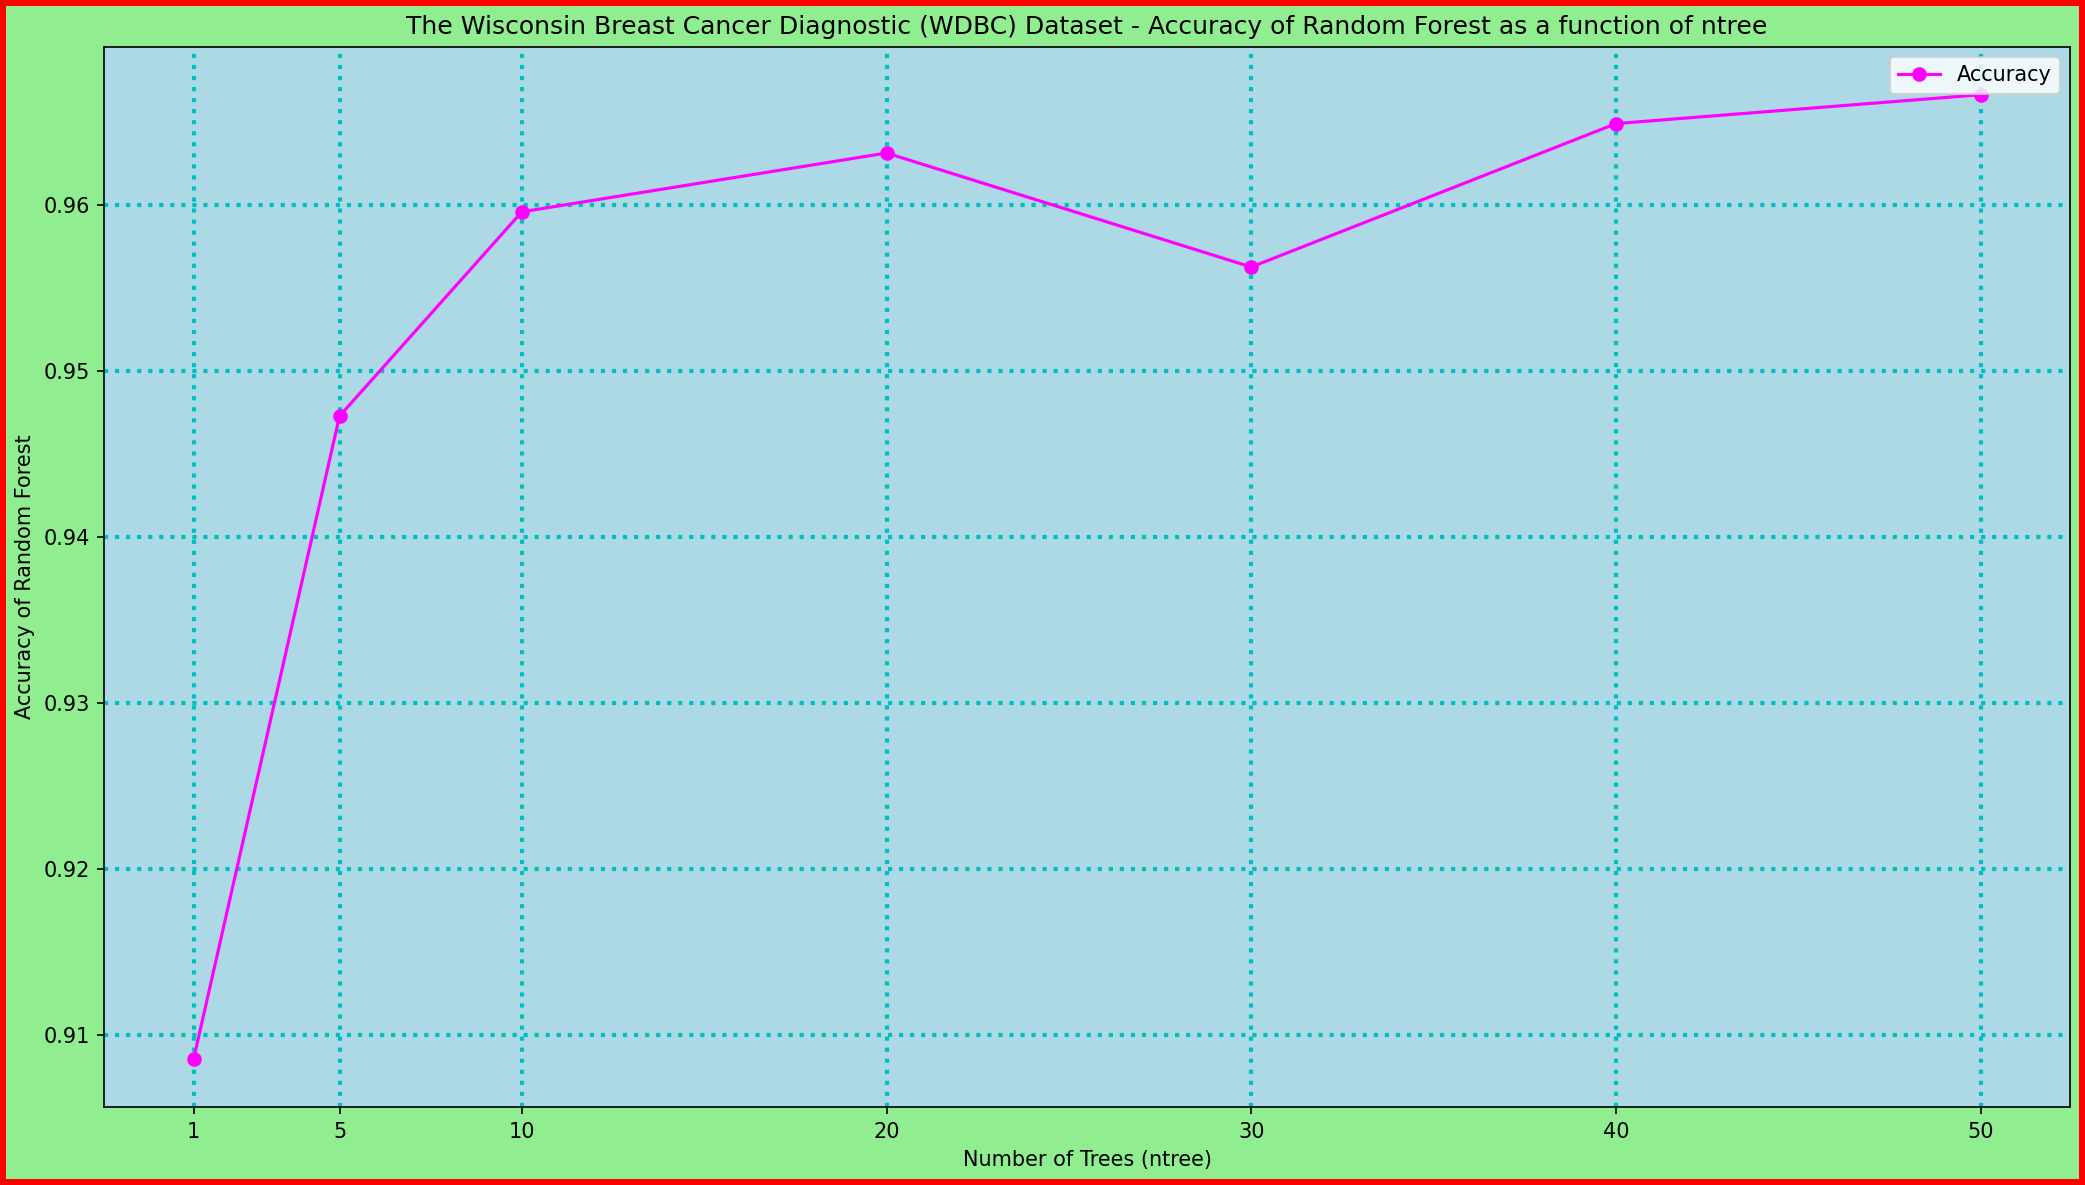

In [38]:
import matplotlib.pyplot as plt

ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### extract metrics for WDBC dataset ####
#### Creates a list and stores the metrics value for each ntree parameter ####
wdbc_accuracy  = [wdbc_results[n]['Accuracy']  for n in ntree_values]
wdbc_precision = [wdbc_results[n]['Precision'] for n in ntree_values]
wdbc_recall    = [wdbc_results[n]['Recall']    for n in ntree_values]
wdbc_f1        = [wdbc_results[n]['F1 Score']  for n in ntree_values]

#### extract metrics for Loan dataset ####
#### Creates a list and stores the metrics value for each ntree parameter ####
loan_accuracy  = [loan_results[n]['Accuracy']  for n in ntree_values]
loan_precision = [loan_results[n]['Precision'] for n in ntree_values]
loan_recall    = [loan_results[n]['Recall']    for n in ntree_values]
loan_f1        = [loan_results[n]['F1 Score']  for n in ntree_values]

#### Plot 1 - WDBC Accuracy ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, wdbc_accuracy, marker='o', color='magenta', label='Accuracy')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Accuracy of Random Forest')
plt.title('The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - Accuracy of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('WDBC_Accuracy.pdf')
plt.show()

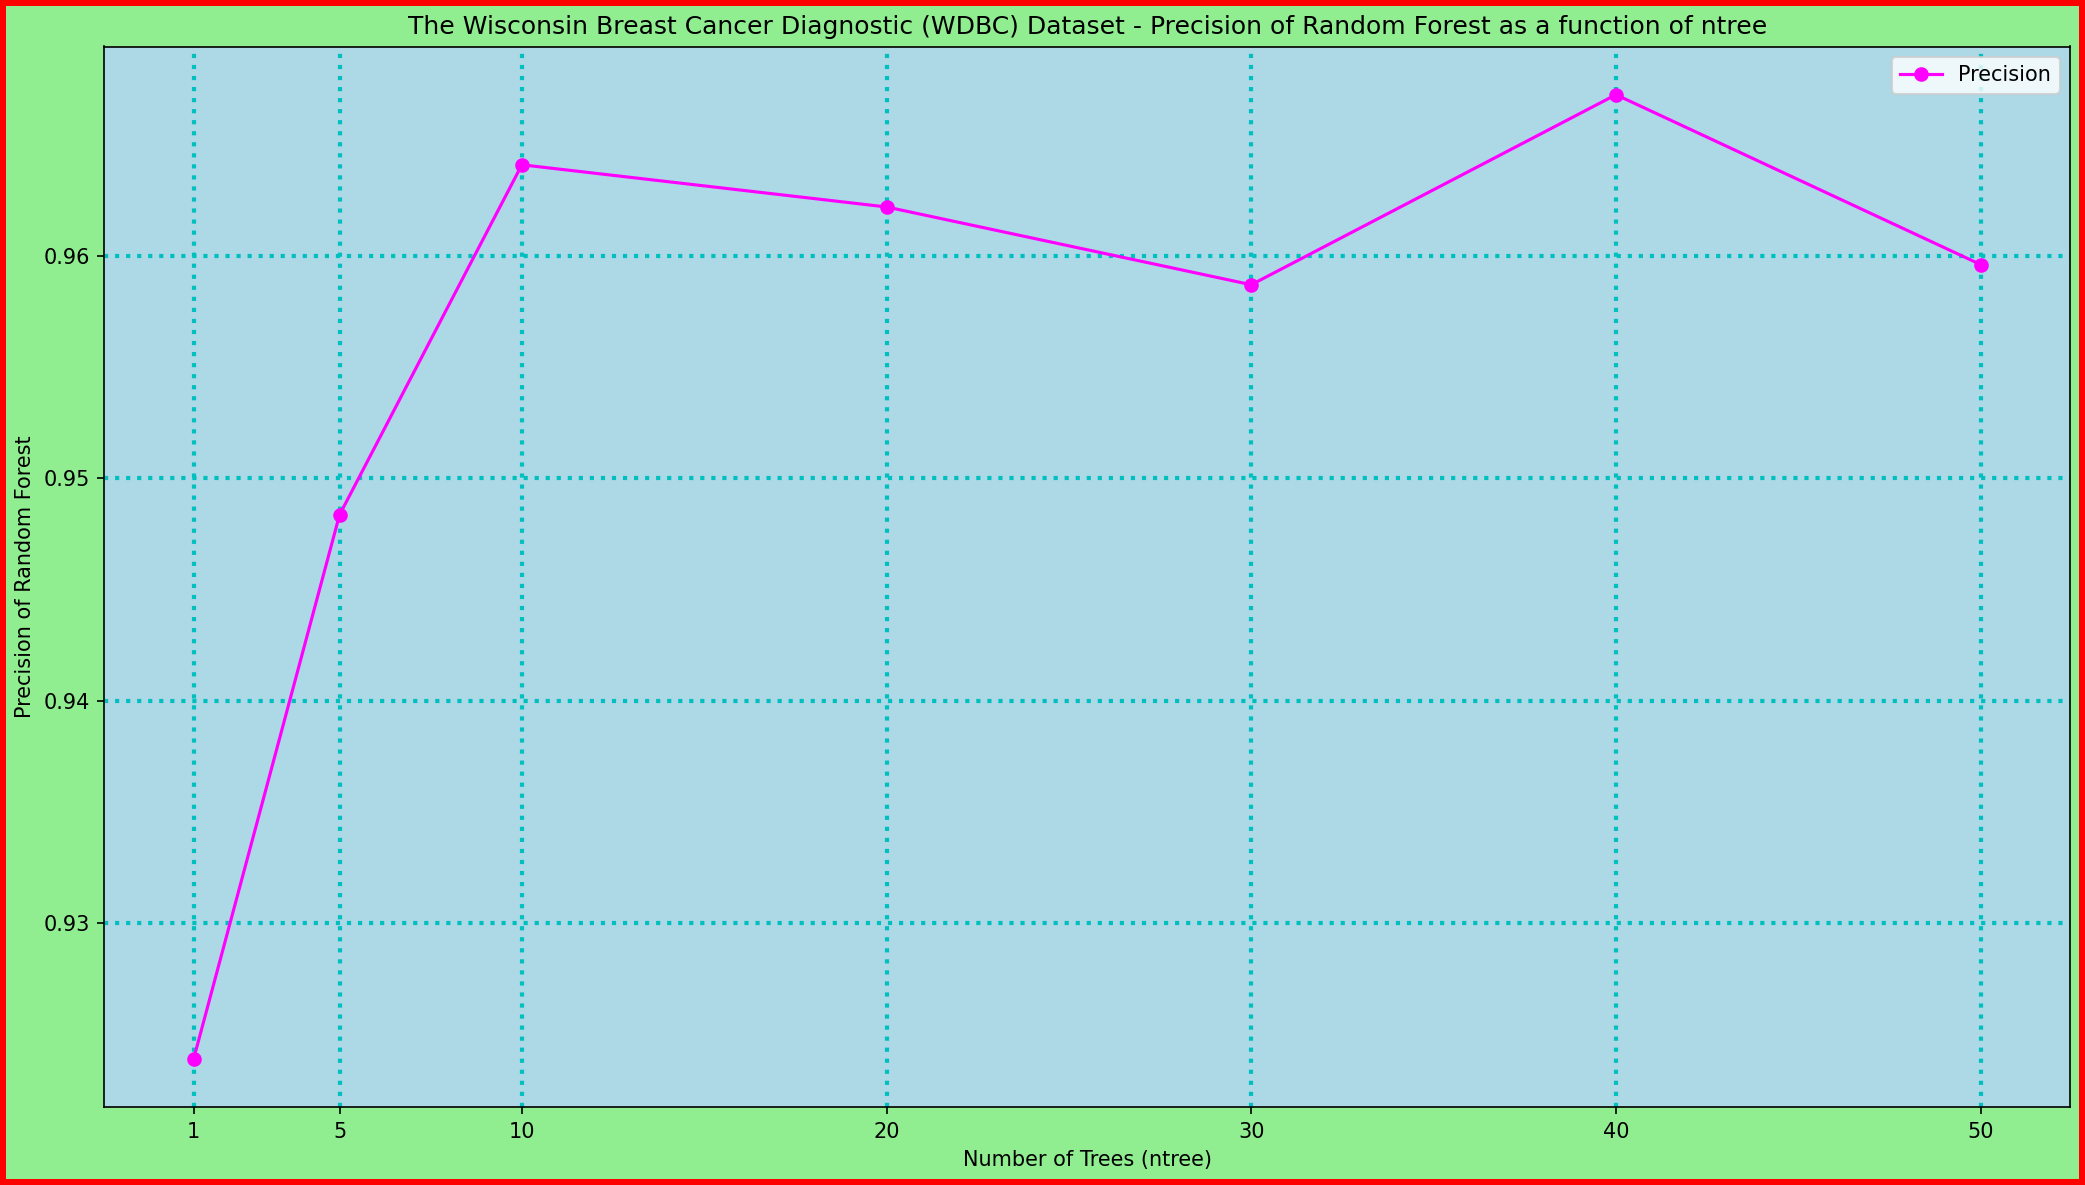

In [40]:
#### Plot 2 - WDBC Precision ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, wdbc_precision, marker='o', color='magenta', label='Precision')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Precision of Random Forest')
plt.title('The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - Precision of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('WDBC_Precision.pdf')
plt.show()

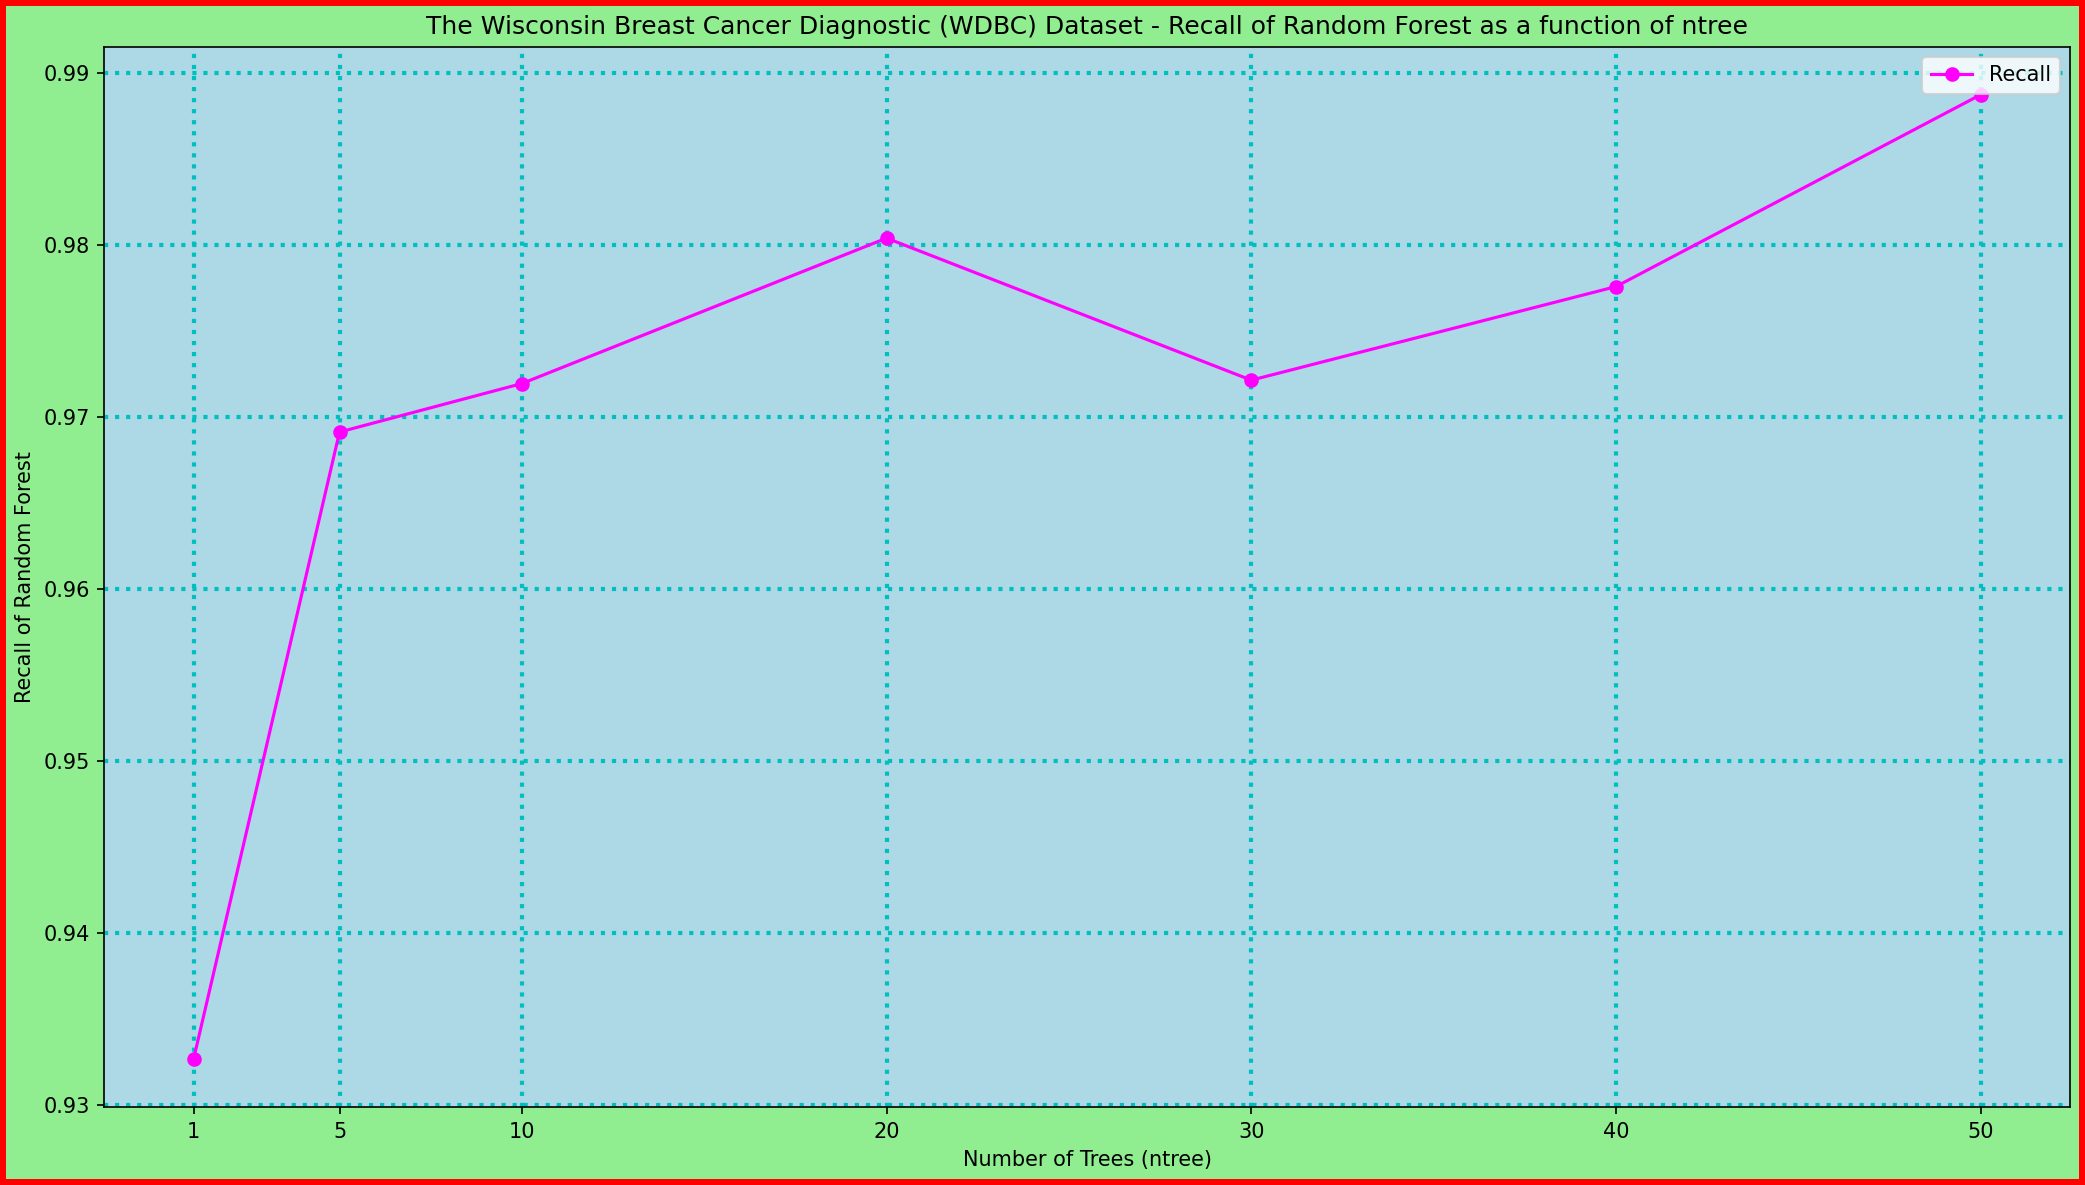

In [42]:
#### Plot 3 - WDBC Recall ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, wdbc_recall, marker='o', color='magenta', label='Recall')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Recall of Random Forest')
plt.title('The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - Recall of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('WDBC_Recall.pdf')
plt.show()

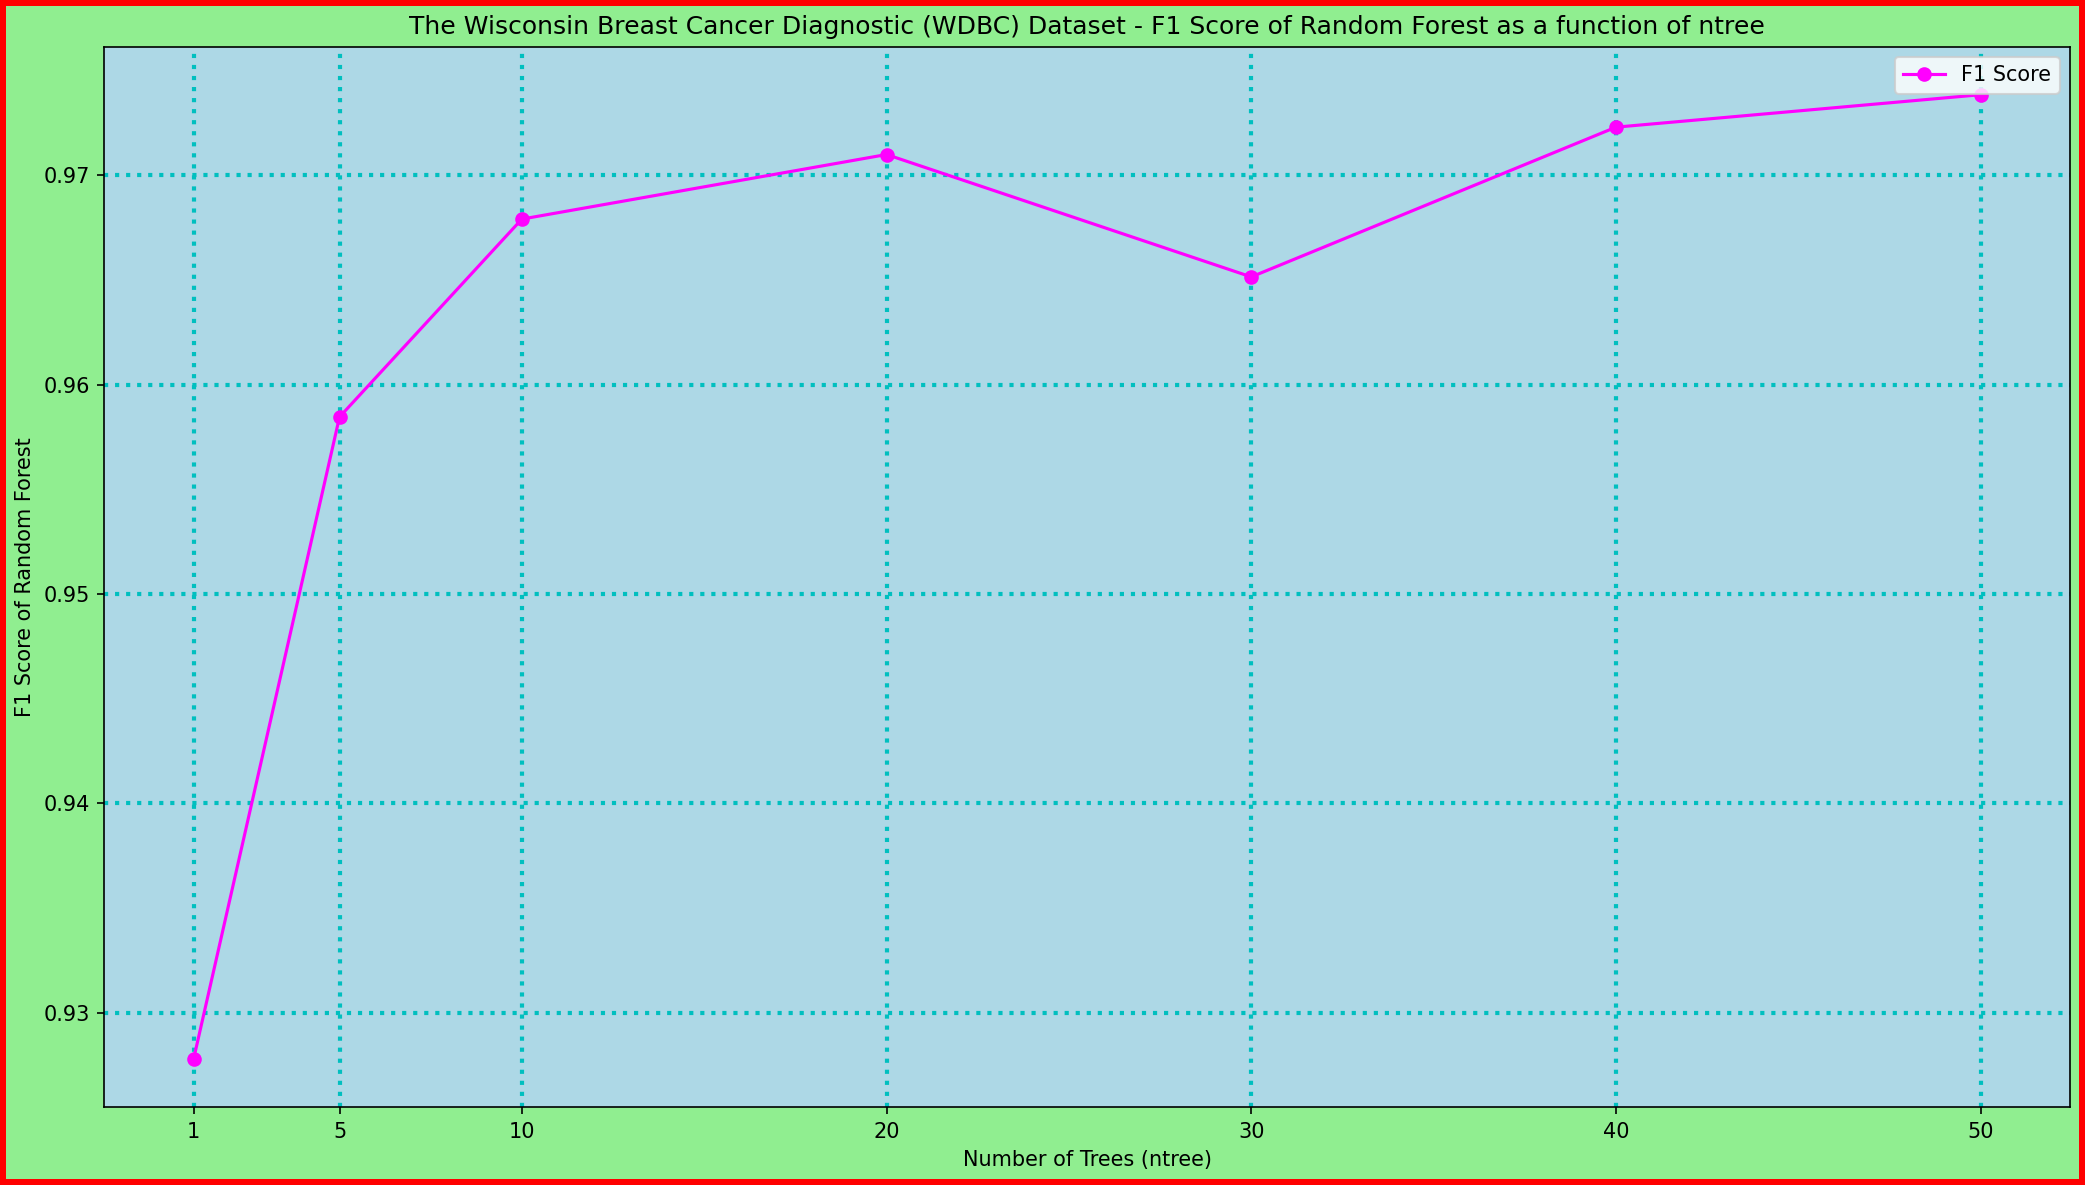

In [80]:
#### Plot 4 - WDBC F1 ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, wdbc_f1, marker='o', color='magenta', label='F1 Score')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('F1 Score of Random Forest')
plt.title('The Wisconsin Breast Cancer Diagnostic (WDBC) Dataset - F1 Score of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('WDBC_F1Score.pdf')
plt.show()

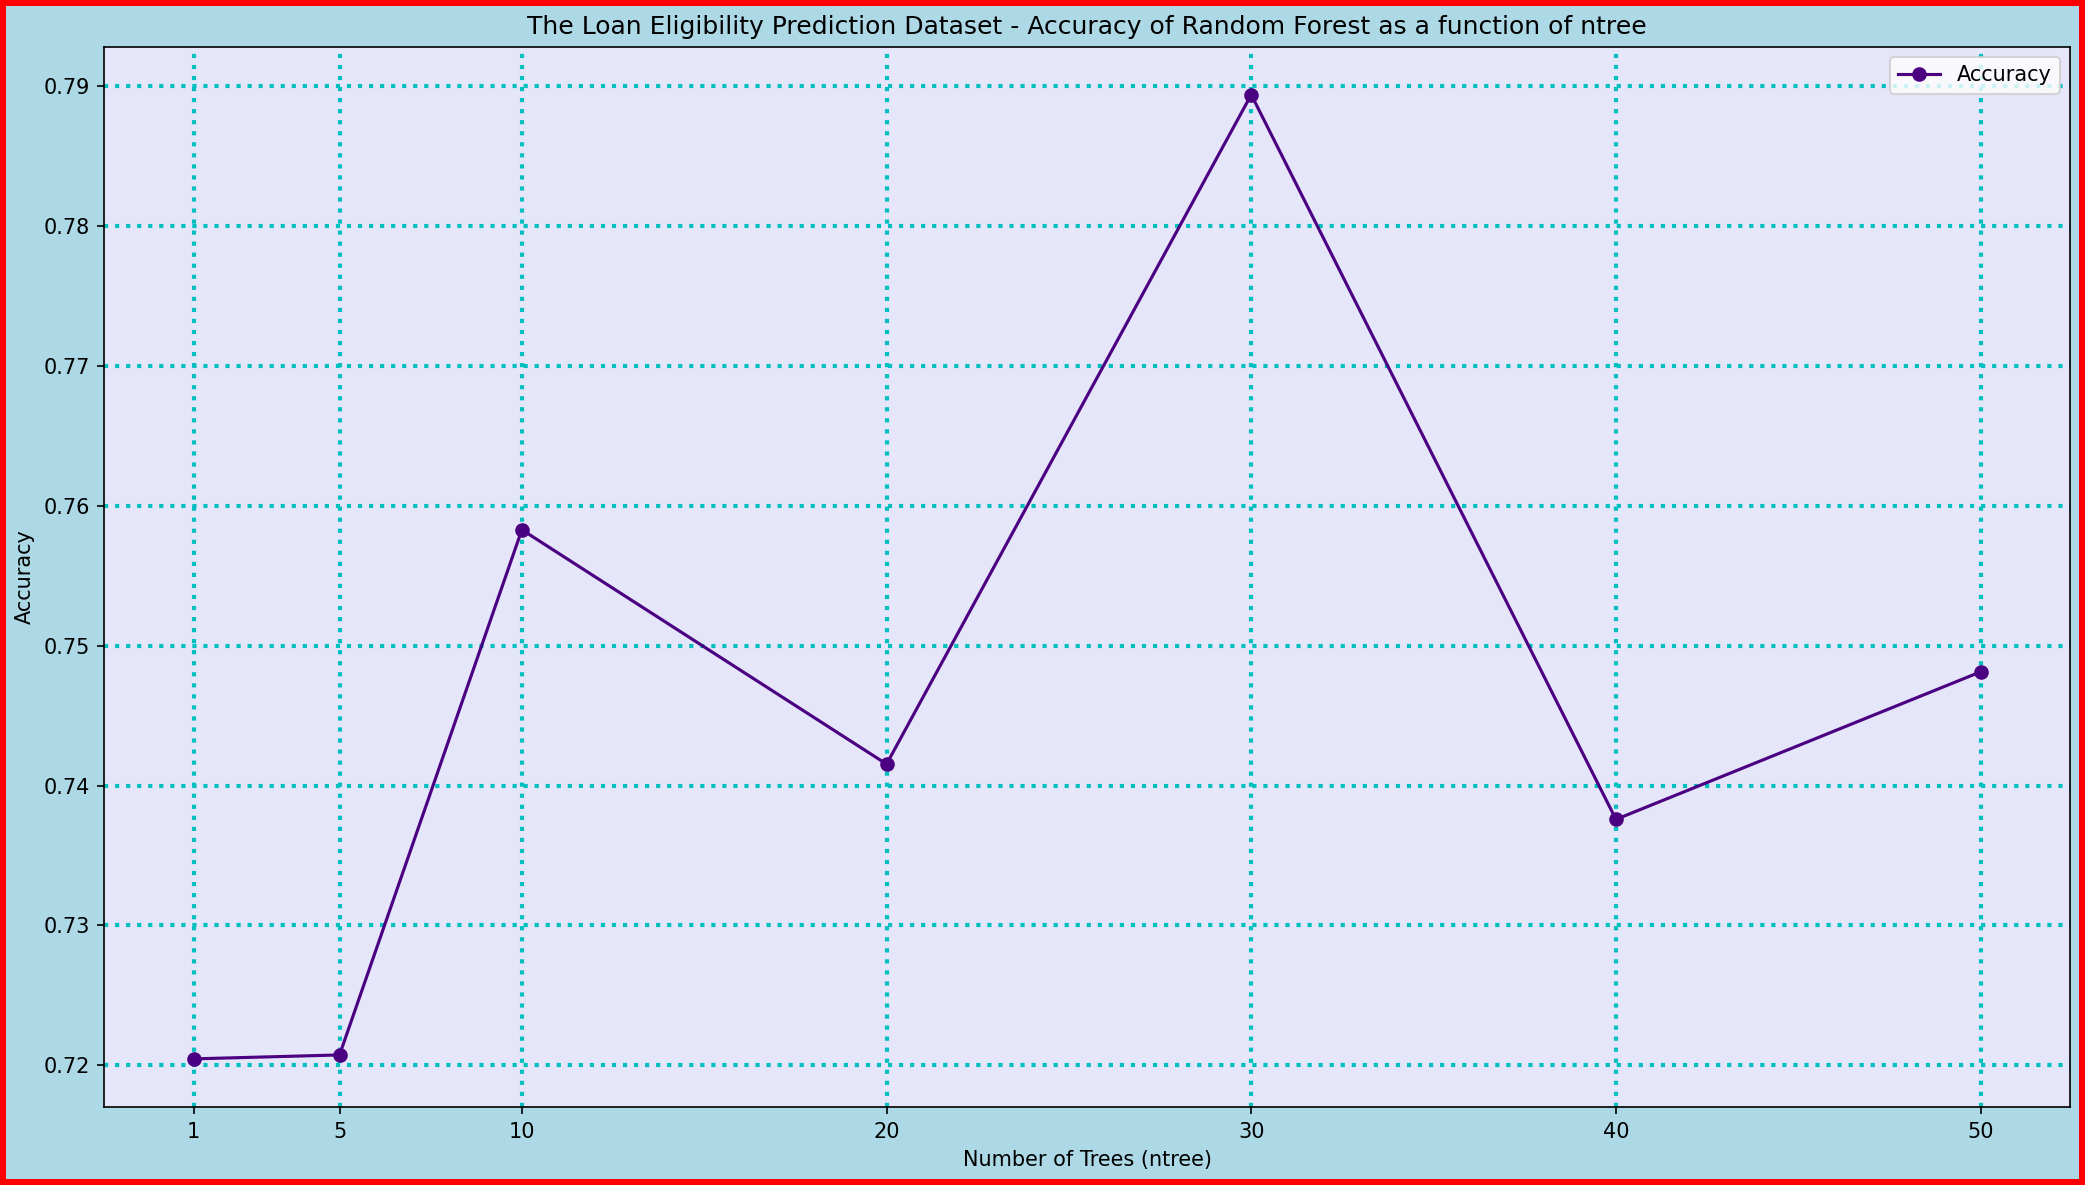

In [46]:
#### Plot 5 - Loan Accuracy ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightblue', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, loan_accuracy, marker='o', color='indigo', label='Accuracy')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Accuracy')
plt.title('The Loan Eligibility Prediction Dataset - Accuracy of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lavender')
plt.savefig('Loan_Accuracy.pdf')
plt.show()

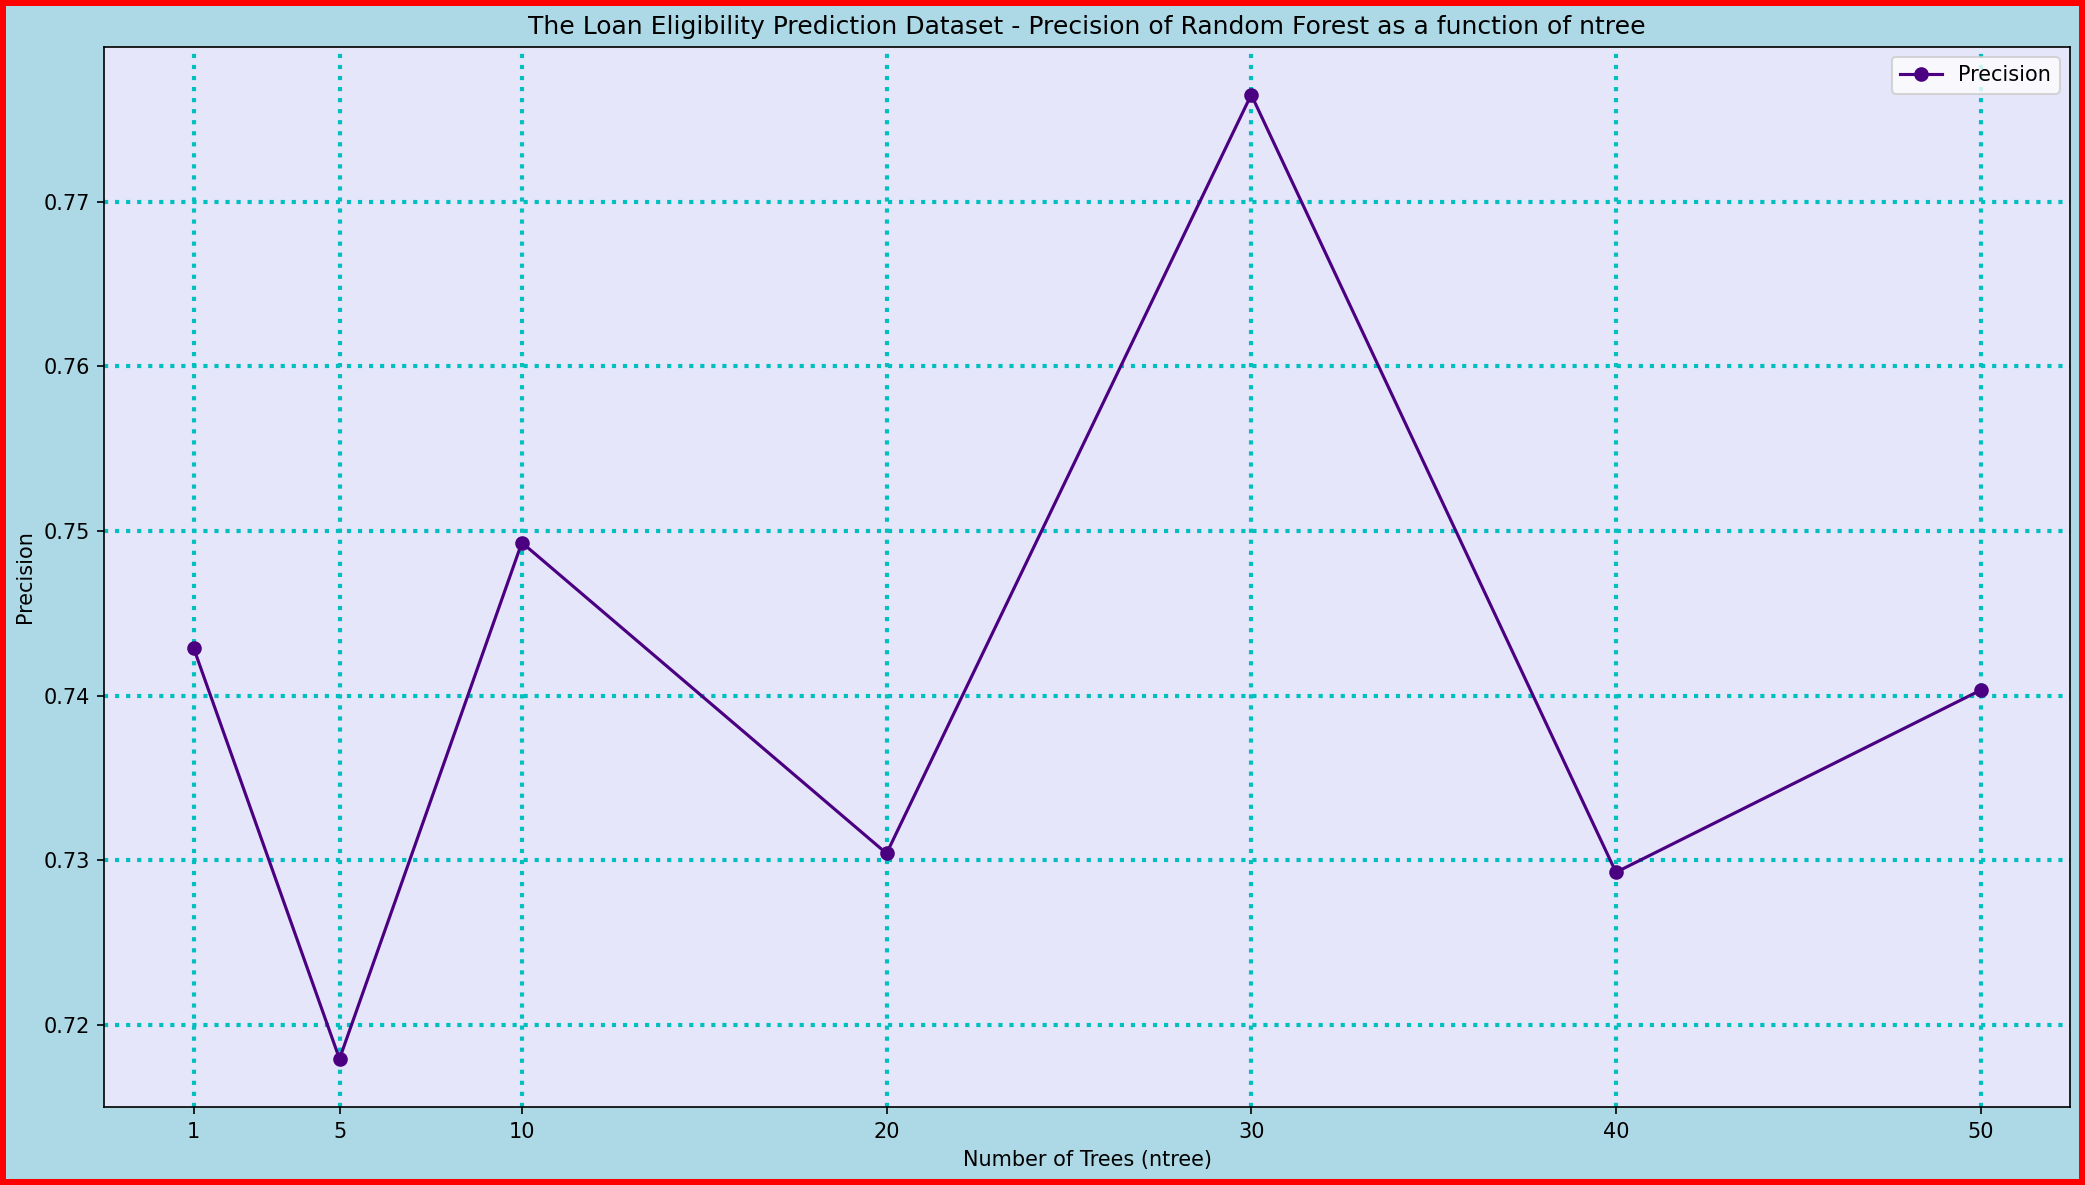

In [48]:
#### Plot 6 - Loan Precision ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightblue', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, loan_precision, marker='o', color='indigo', label='Precision')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Precision')
plt.title('The Loan Eligibility Prediction Dataset - Precision of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lavender')
plt.savefig('Loan_Precision.pdf')
plt.show()

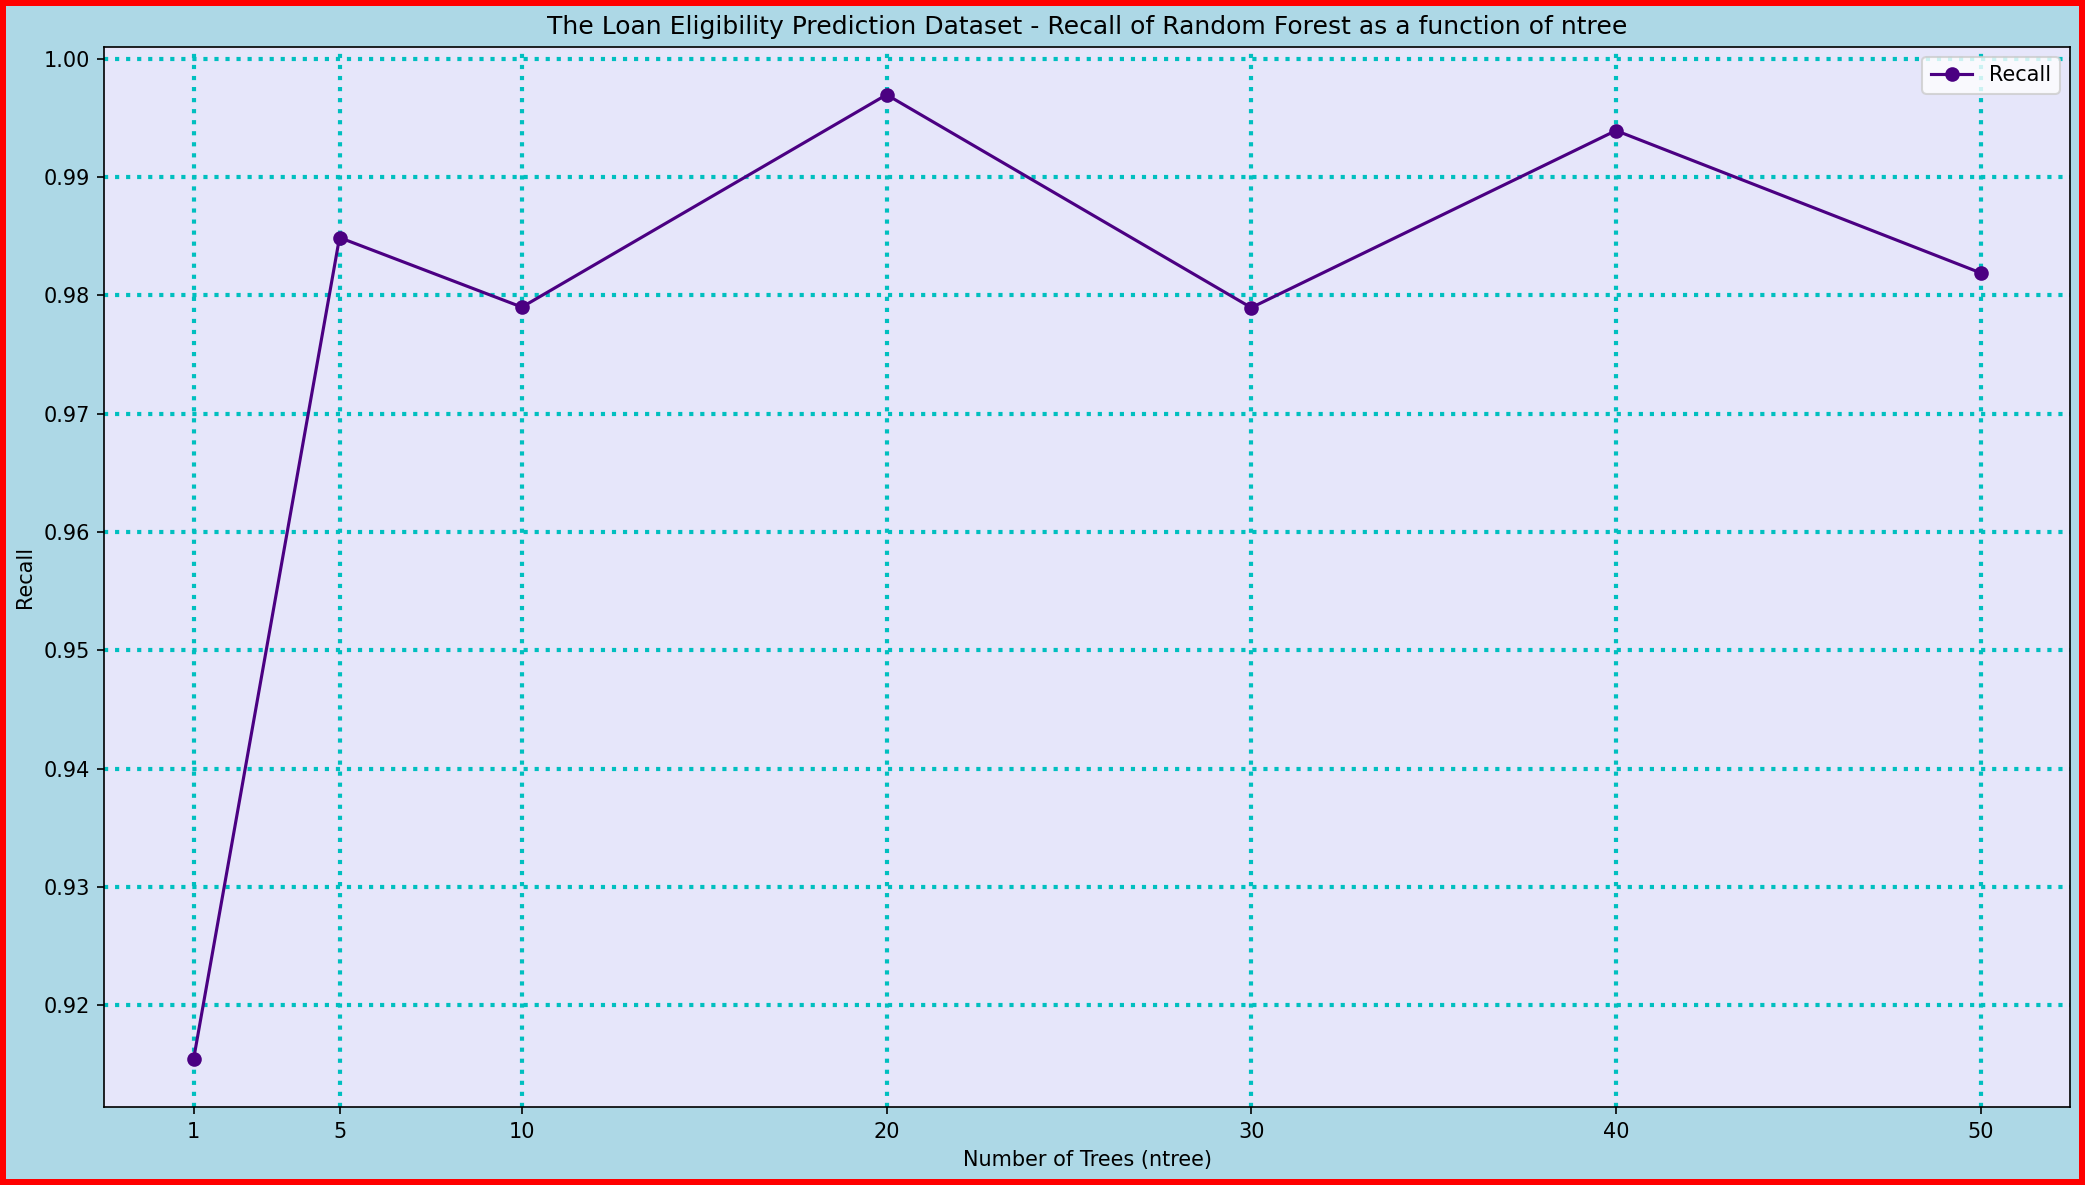

In [50]:
#### Plot 7 - Loan Recall ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightblue', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, loan_recall, marker='o', color='indigo', label='Recall')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Recall')
plt.title('The Loan Eligibility Prediction Dataset - Recall of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lavender')
plt.savefig('Loan_Recall.pdf')
plt.show()

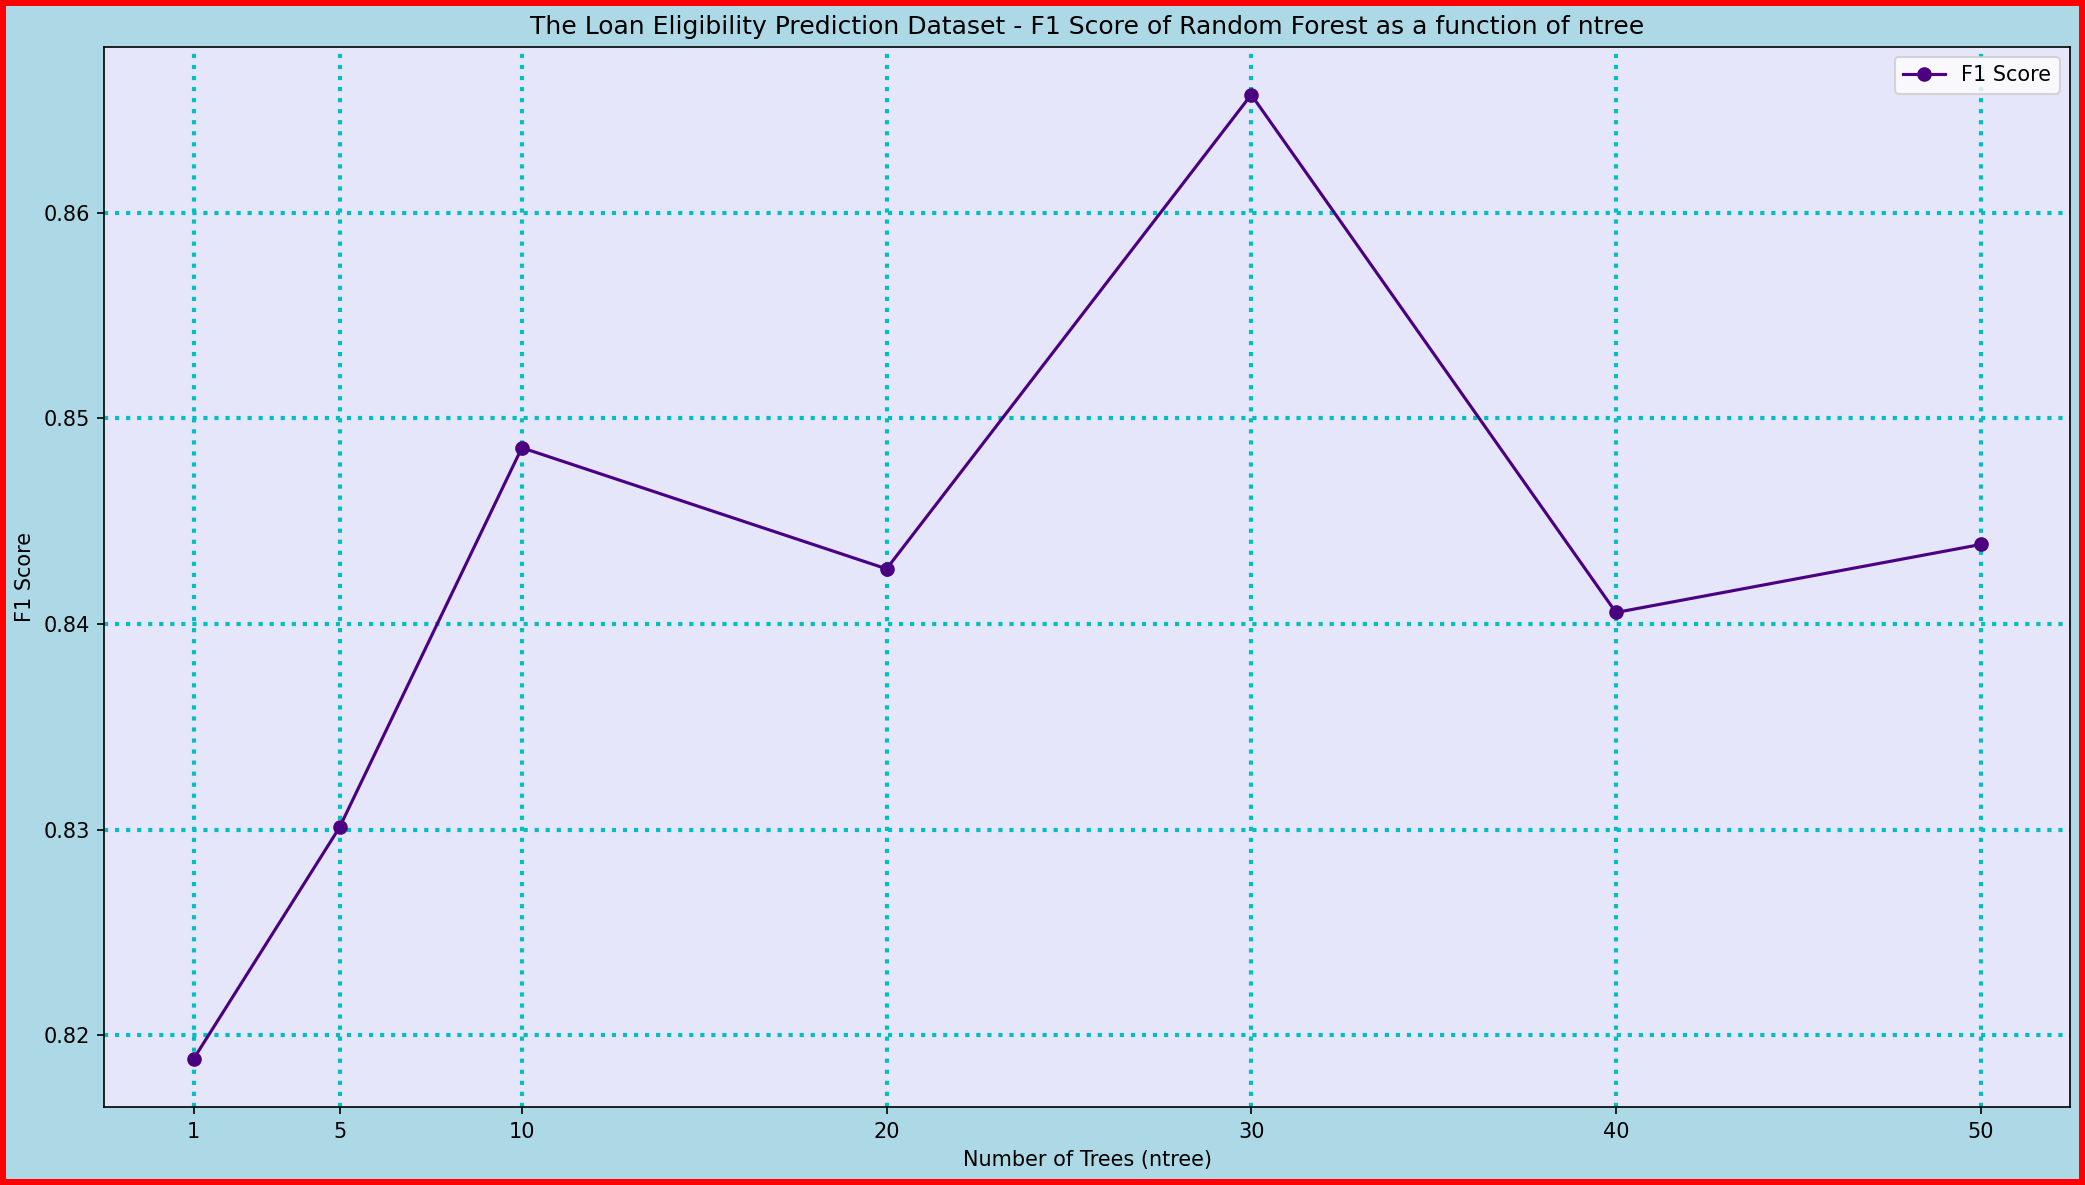

In [84]:
#### Plot 8 - Loan F1 ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightblue', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, loan_f1, marker='o', color='indigo', label='F1 Score')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('F1 Score')
plt.title('The Loan Eligibility Prediction Dataset - F1 Score of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lavender')
plt.savefig('Loan_F1Score.pdf')
plt.show()

In [54]:
#### Added in HW 3 ####

#### reads the 'raisin.csv' file ####
raisin = pd.read_csv('raisin.csv')

#### Drops the 'label' column from the raisin dataframe and assigns to the X_raisin ####
#### .values - Converts the pandas Dataframe to Numpy Arrays ####
#### Bootstrap dataset needs Numpy Arrays ####
X_raisin = raisin.drop(columns=['label']).values

#### Assigns the 'label' column from the raisin dataframe to the y_raisin ####
#### .values - Converts the pandas Series to Numpy Arrays ####
y_raisin = raisin['label'].values

#### raisin.drop(columns=['label']) - drops the label column from the raisin dataframe ####
#### (raisin.drop(columns=['label']).columns) - picks the column names for all the columns of the raisin dataframe except label column ####
#### list() - converts the column names to list ####
feature_names_raisin = list(raisin.drop(columns=['label']).columns)

print("The Raisin Dataset:")
print("X shape:", X_raisin.shape)
print("y shape:", y_raisin.shape)
print("Features:", feature_names_raisin)

The Raisin Dataset:
X shape: (900, 7)
y shape: (900,)
Features: ['attr1_num', 'attr2_num', 'attr3_num', 'attr4_num', 'attr5_num', 'attr6_num', 'attr7_num']


In [56]:
#### Added in HW 3 ####

#### reads the 'titanic.csv' file and assigns to titanic dataframe ####
titanic = pd.read_csv('titanic.csv')

#### Drops the 'label' column from the titanic dataframe and assigns to the X_titanic ####
#### .values - Converts the pandas Dataframe to Numpy Arrays ####
#### Bootstrap dataset needs Numpy Arrays ####
X_titanic = titanic.drop(columns=['label']).values

#### Assigns the 'label' column from the titanic dataframe to the y_titanic ####
#### .values - Converts the pandas Series to Numpy Arrays ####
y_titanic = titanic['label'].values

#### titanic.drop(columns=['label']) - drops the label column from the titanic dataframe ####
#### (titanic.drop(columns=['label']).columns) - picks the column names for all the columns of the titanic dataframe except label column ####
#### list() - converts the column names to list ####
feature_names_titanic = list(titanic.drop(columns=['label']).columns)

print("The Titanic Dataset:")
print("X shape:", X_titanic.shape)
print("y shape:", y_titanic.shape)
print("Features:", feature_names_titanic)

The Titanic Dataset:
X shape: (887, 6)
y shape: (887,)
Features: ['attr1_cat', 'attr2_cat', 'attr3_num', 'attr4_num', 'attr5_num', 'attr6_num']


In [58]:
#### Added in HW 3 ####

#### Different values of ntree parameter ####
ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### Create a empty dictionary for raisin_results ####
raisin_results = {}

for ntree in ntree_values:
    #### iterate a for loop for each values from the ntree_values list ####
    print(f"The Raisin Dataset - ntree parameter = {ntree}")
    #### Prints the header for each ntree value ####

    #### Runs the cross validation for current ntree value ####
    #### stores the result in the raisin_result dictionary with ntree value as key ####    
    raisin_results[ntree] = cross_validate_rf(X_raisin, y_raisin, feature_names_raisin, ntree=ntree)

    #### Prints accuracy, precision, recall, f1 score for each ntree value ####
    print(raisin_results[ntree])

The Raisin Dataset - ntree parameter = 1
{'Accuracy': 0.807778, 'Precision': 0.829283, 'Recall': 0.777778, 'F1 Score': 0.801578}
The Raisin Dataset - ntree parameter = 5
{'Accuracy': 0.856667, 'Precision': 0.875018, 'Recall': 0.833333, 'F1 Score': 0.853075}
The Raisin Dataset - ntree parameter = 10
{'Accuracy': 0.86, 'Precision': 0.897012, 'Recall': 0.813333, 'F1 Score': 0.853105}
The Raisin Dataset - ntree parameter = 20
{'Accuracy': 0.855556, 'Precision': 0.895405, 'Recall': 0.806667, 'F1 Score': 0.847908}
The Raisin Dataset - ntree parameter = 30
{'Accuracy': 0.87, 'Precision': 0.895008, 'Recall': 0.84, 'F1 Score': 0.865977}
The Raisin Dataset - ntree parameter = 40
{'Accuracy': 0.867778, 'Precision': 0.904038, 'Recall': 0.824444, 'F1 Score': 0.861638}
The Raisin Dataset - ntree parameter = 50
{'Accuracy': 0.86, 'Precision': 0.897937, 'Recall': 0.815556, 'F1 Score': 0.852739}


In [60]:
#### Added in HW 3 ####

#### Different values of ntree parameter ####
ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### Create a empty dictionary for titanic_results ####
titanic_results = {}

for ntree in ntree_values:
    #### iterate a for loop for each values from the ntree_values list ####
    print(f"The Titanic Dataset - ntree={ntree}")
    #### Prints the header for each ntree value ####

    #### Runs the cross validation for current ntree value ####
    #### stores the result in the titanic_result dictionary with ntree value as key ####     
    titanic_results[ntree] = cross_validate_rf(X_titanic, y_titanic, feature_names_titanic, ntree=ntree)

    #### Prints accuracy, precision, recall, f1 score for each ntree value ####
    print(titanic_results[ntree])

The Titanic Dataset - ntree=1
{'Accuracy': 0.772361, 'Precision': 0.766259, 'Recall': 0.640111, 'F1 Score': 0.686088}
The Titanic Dataset - ntree=5
{'Accuracy': 0.793646, 'Precision': 0.834283, 'Recall': 0.593606, 'F1 Score': 0.685535}
The Titanic Dataset - ntree=10
{'Accuracy': 0.801619, 'Precision': 0.829024, 'Recall': 0.61445, 'F1 Score': 0.703315}
The Titanic Dataset - ntree=20
{'Accuracy': 0.790288, 'Precision': 0.852979, 'Recall': 0.564109, 'F1 Score': 0.670043}
The Titanic Dataset - ntree=30
{'Accuracy': 0.795956, 'Precision': 0.852635, 'Recall': 0.576257, 'F1 Score': 0.684613}
The Titanic Dataset - ntree=40
{'Accuracy': 0.807173, 'Precision': 0.829133, 'Recall': 0.628389, 'F1 Score': 0.713655}
The Titanic Dataset - ntree=50
{'Accuracy': 0.800482, 'Precision': 0.869716, 'Recall': 0.579071, 'F1 Score': 0.686915}


In [62]:
#### extract metrics for Raisin dataset ####
#### Creates a list and stores the metrics value for each ntree parameter ####
raisin_accuracy  = [raisin_results[n]['Accuracy']  for n in ntree_values]
raisin_precision = [raisin_results[n]['Precision'] for n in ntree_values]
raisin_recall    = [raisin_results[n]['Recall']    for n in ntree_values]
raisin_f1        = [raisin_results[n]['F1 Score']  for n in ntree_values]

#### extract metrics for Titanic dataset ####
#### Creates a list and stores the metrics value for each ntree parameter ####
titanic_accuracy  = [titanic_results[n]['Accuracy']  for n in ntree_values]
titanic_precision = [titanic_results[n]['Precision'] for n in ntree_values]
titanic_recall    = [titanic_results[n]['Recall']    for n in ntree_values]
titanic_f1        = [titanic_results[n]['F1 Score']  for n in ntree_values]

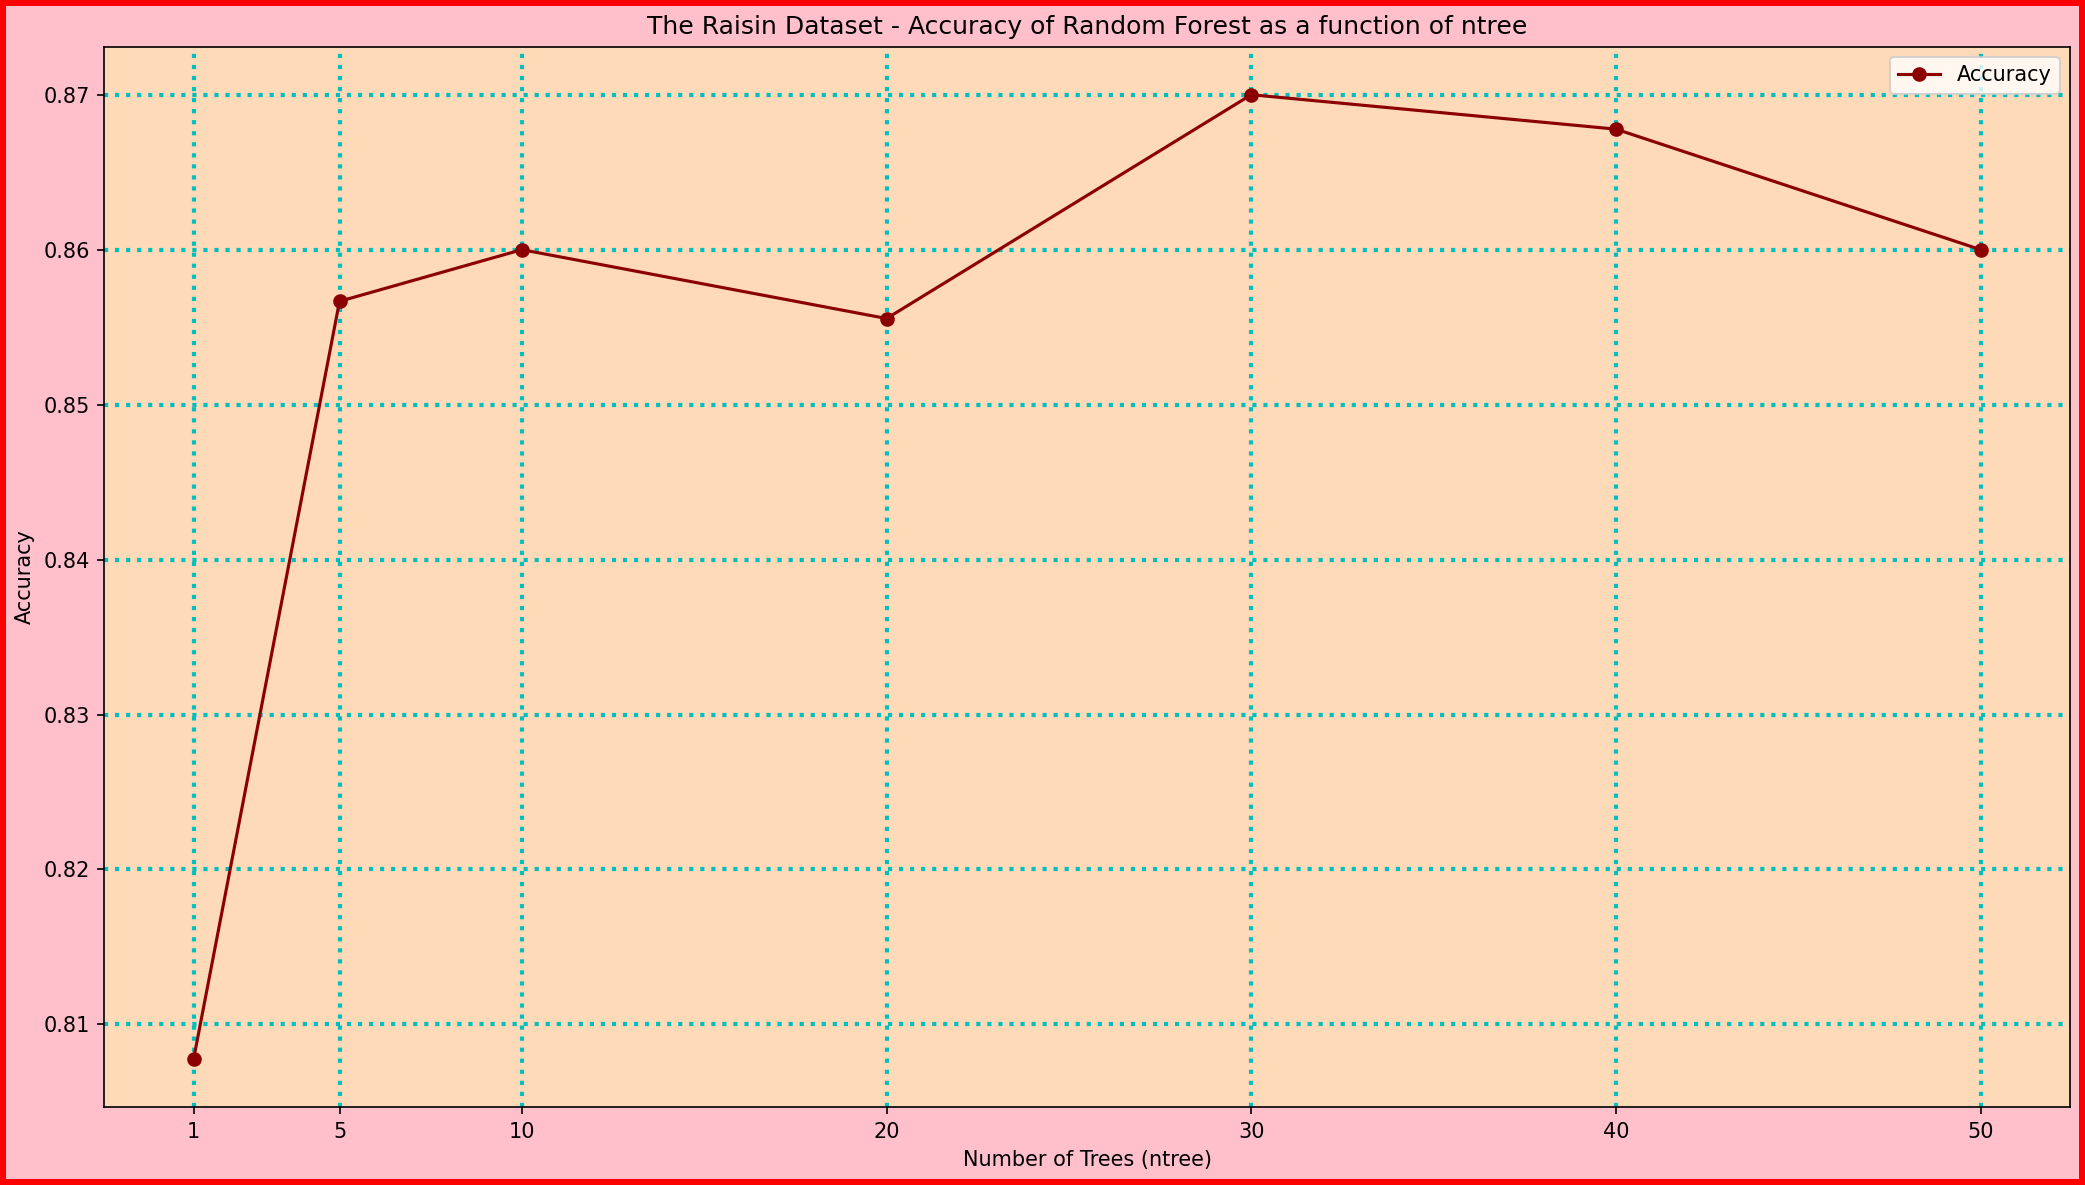

In [64]:
#### Plot 9 - Raisin Accuracy ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='pink', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, raisin_accuracy, marker='o', color='darkred', label='Accuracy')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Accuracy')
plt.title('The Raisin Dataset - Accuracy of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('peachpuff')
plt.savefig('Raisin_Accuracy.pdf')
plt.show()

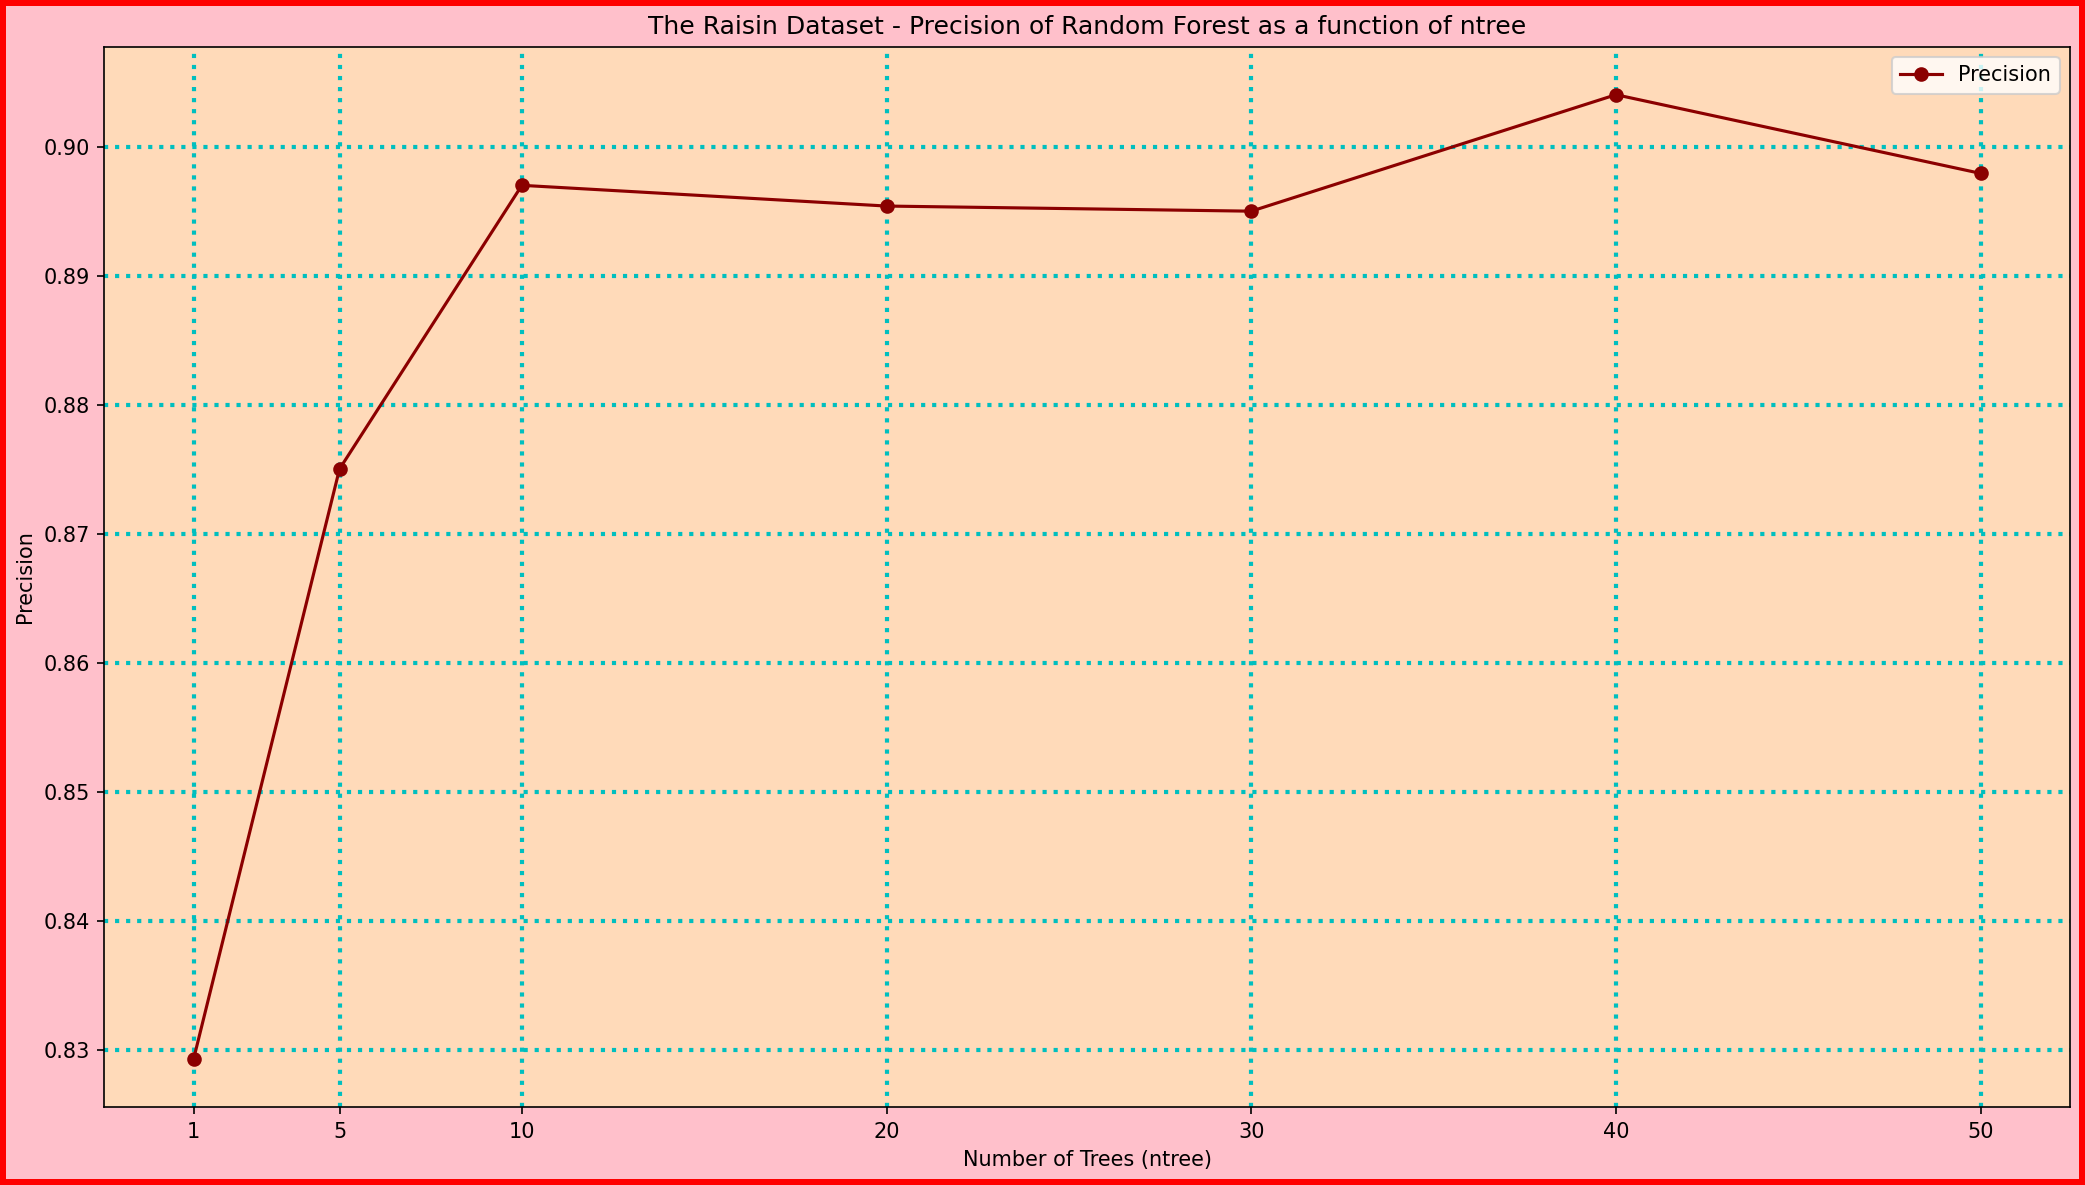

In [66]:
#### Plot 10 - Raisin Precision ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='pink', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, raisin_precision, marker='o', color='darkred', label='Precision')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Precision')
plt.title('The Raisin Dataset - Precision of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('peachpuff')
plt.savefig('Raisin_Precision.pdf')
plt.show()

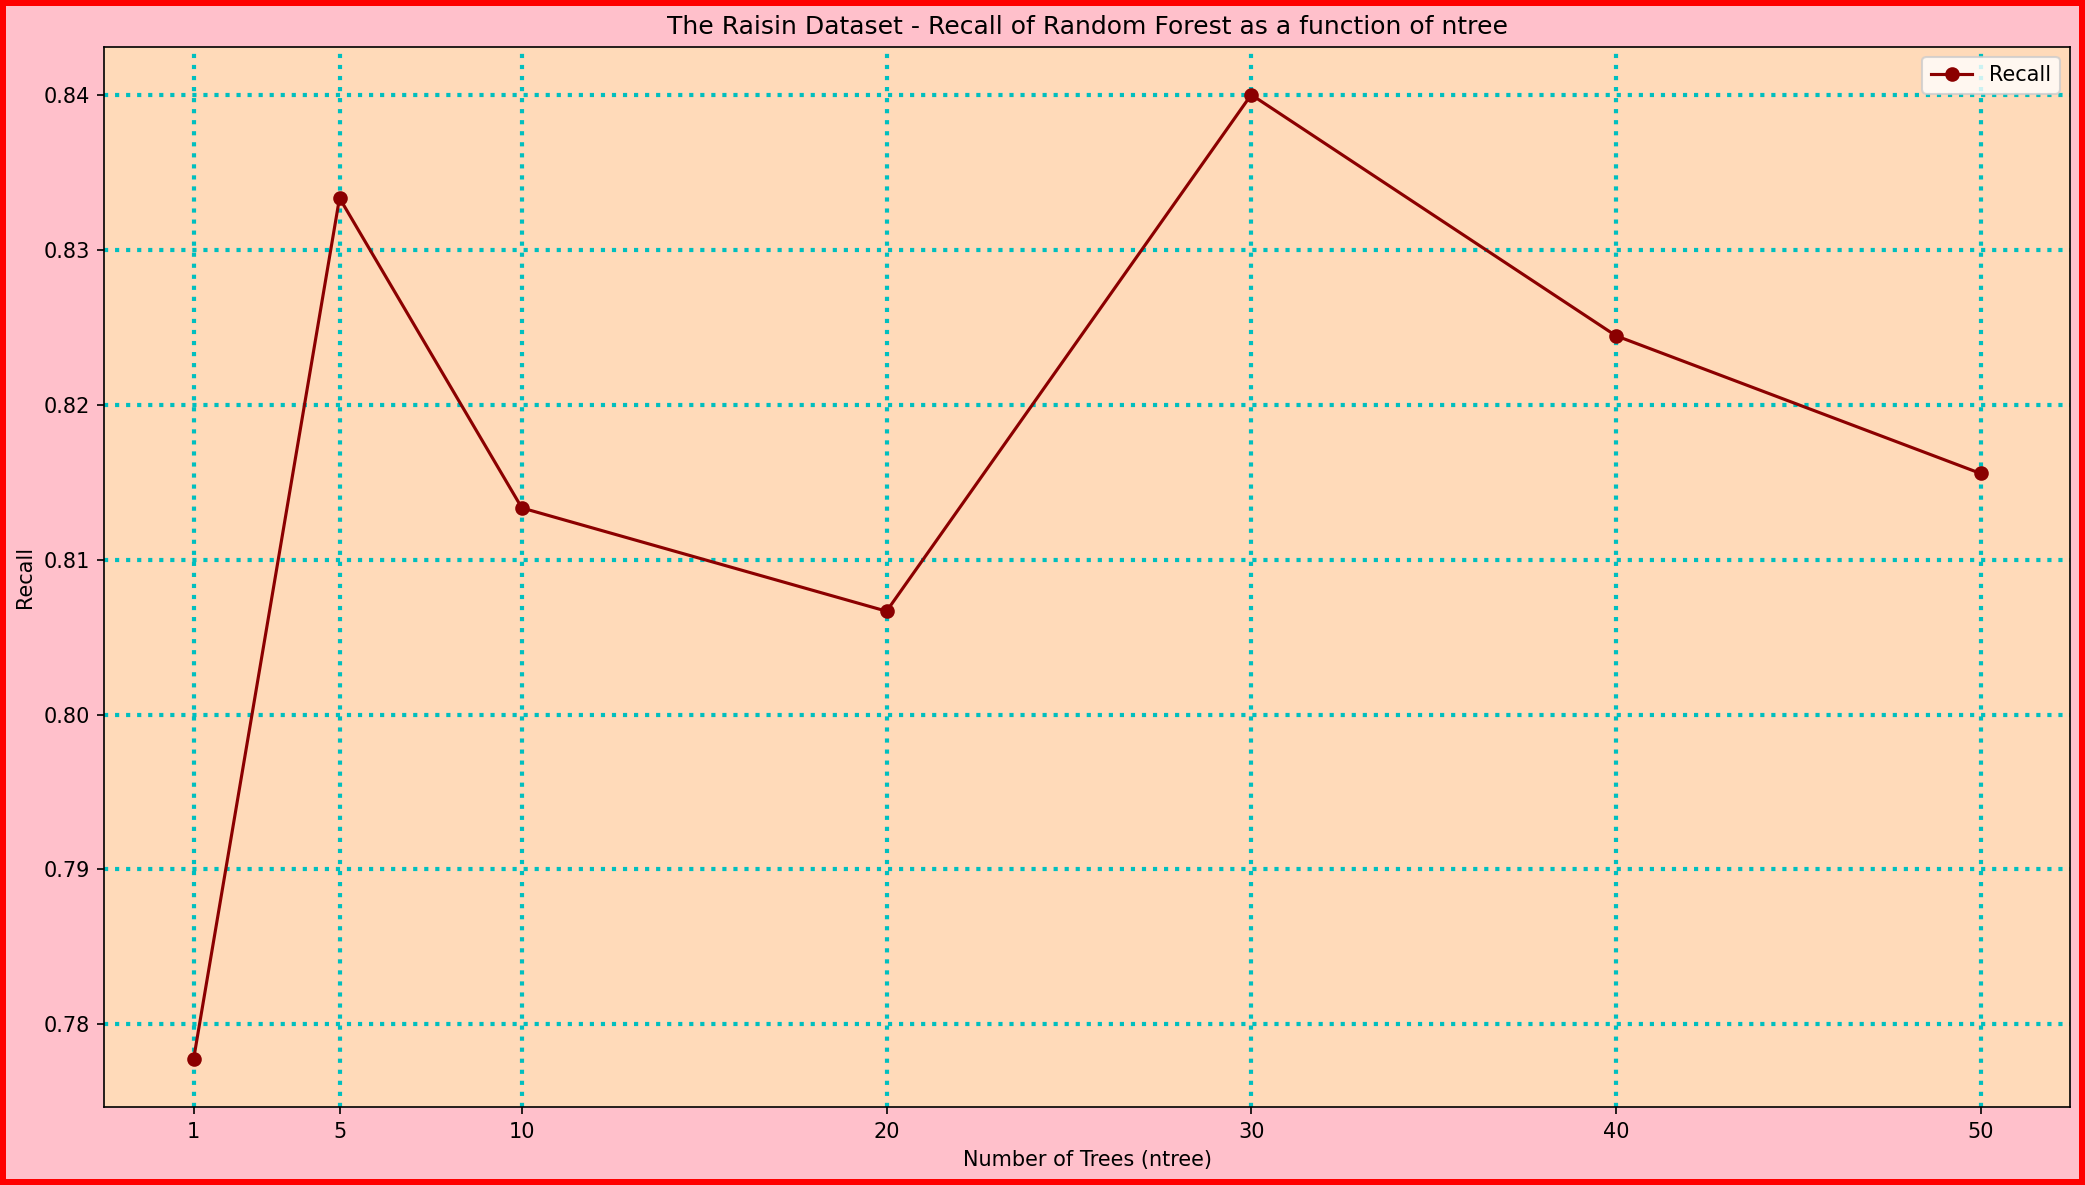

In [68]:
#### Plot 11 - Raisin Recall ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='pink', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, raisin_recall, marker='o', color='darkred', label='Recall')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Recall')
plt.title('The Raisin Dataset - Recall of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('peachpuff')
plt.savefig('Raisin_Recall.pdf')
plt.show()

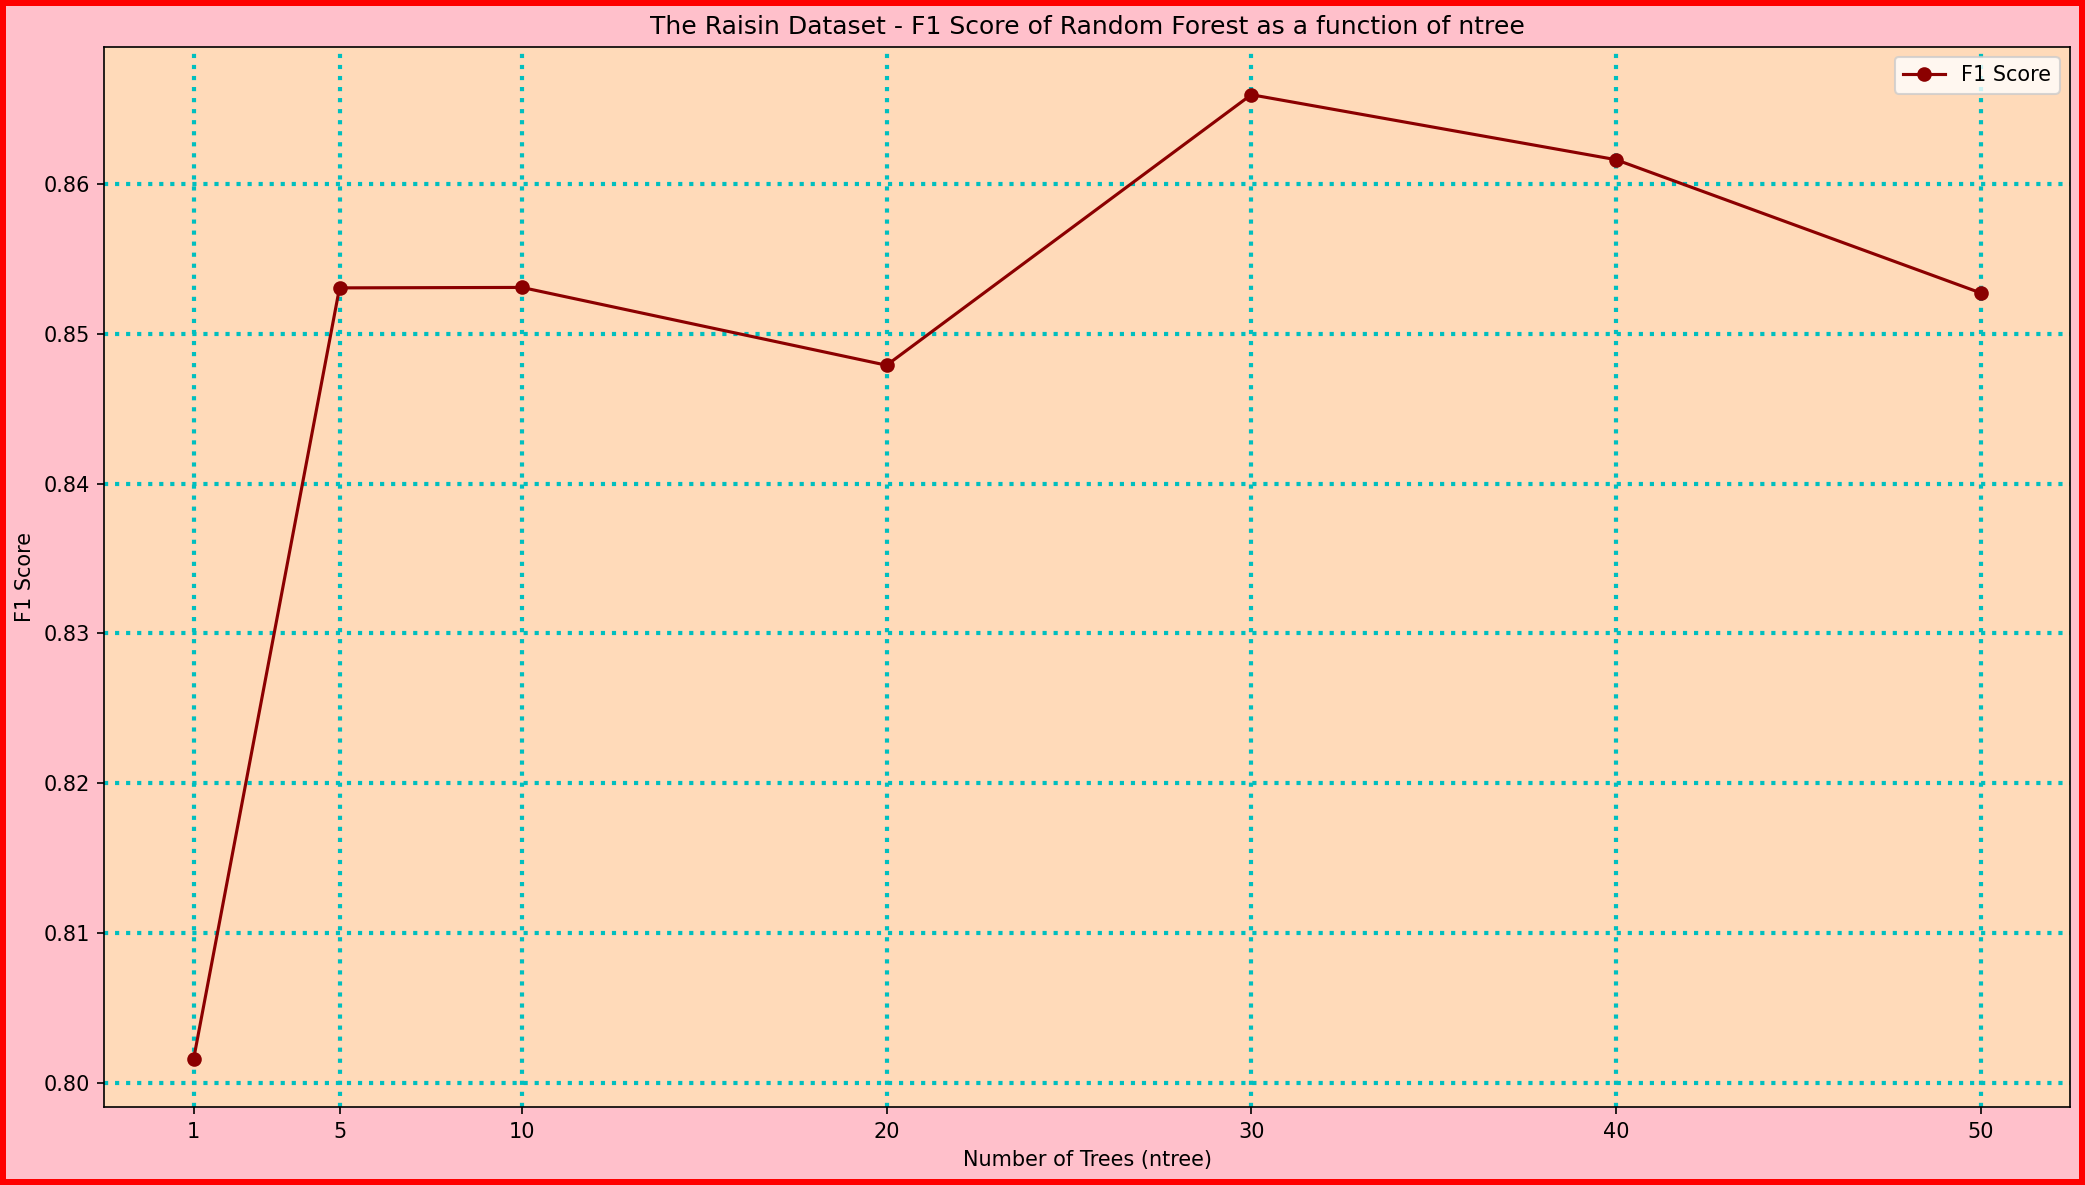

In [70]:
#### Plot 12 - Raisin F1 ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='pink', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, raisin_f1, marker='o', color='darkred', label='F1 Score')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('F1 Score')
plt.title('The Raisin Dataset - F1 Score of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('peachpuff')
plt.savefig('Raisin_F1.pdf')
plt.show()

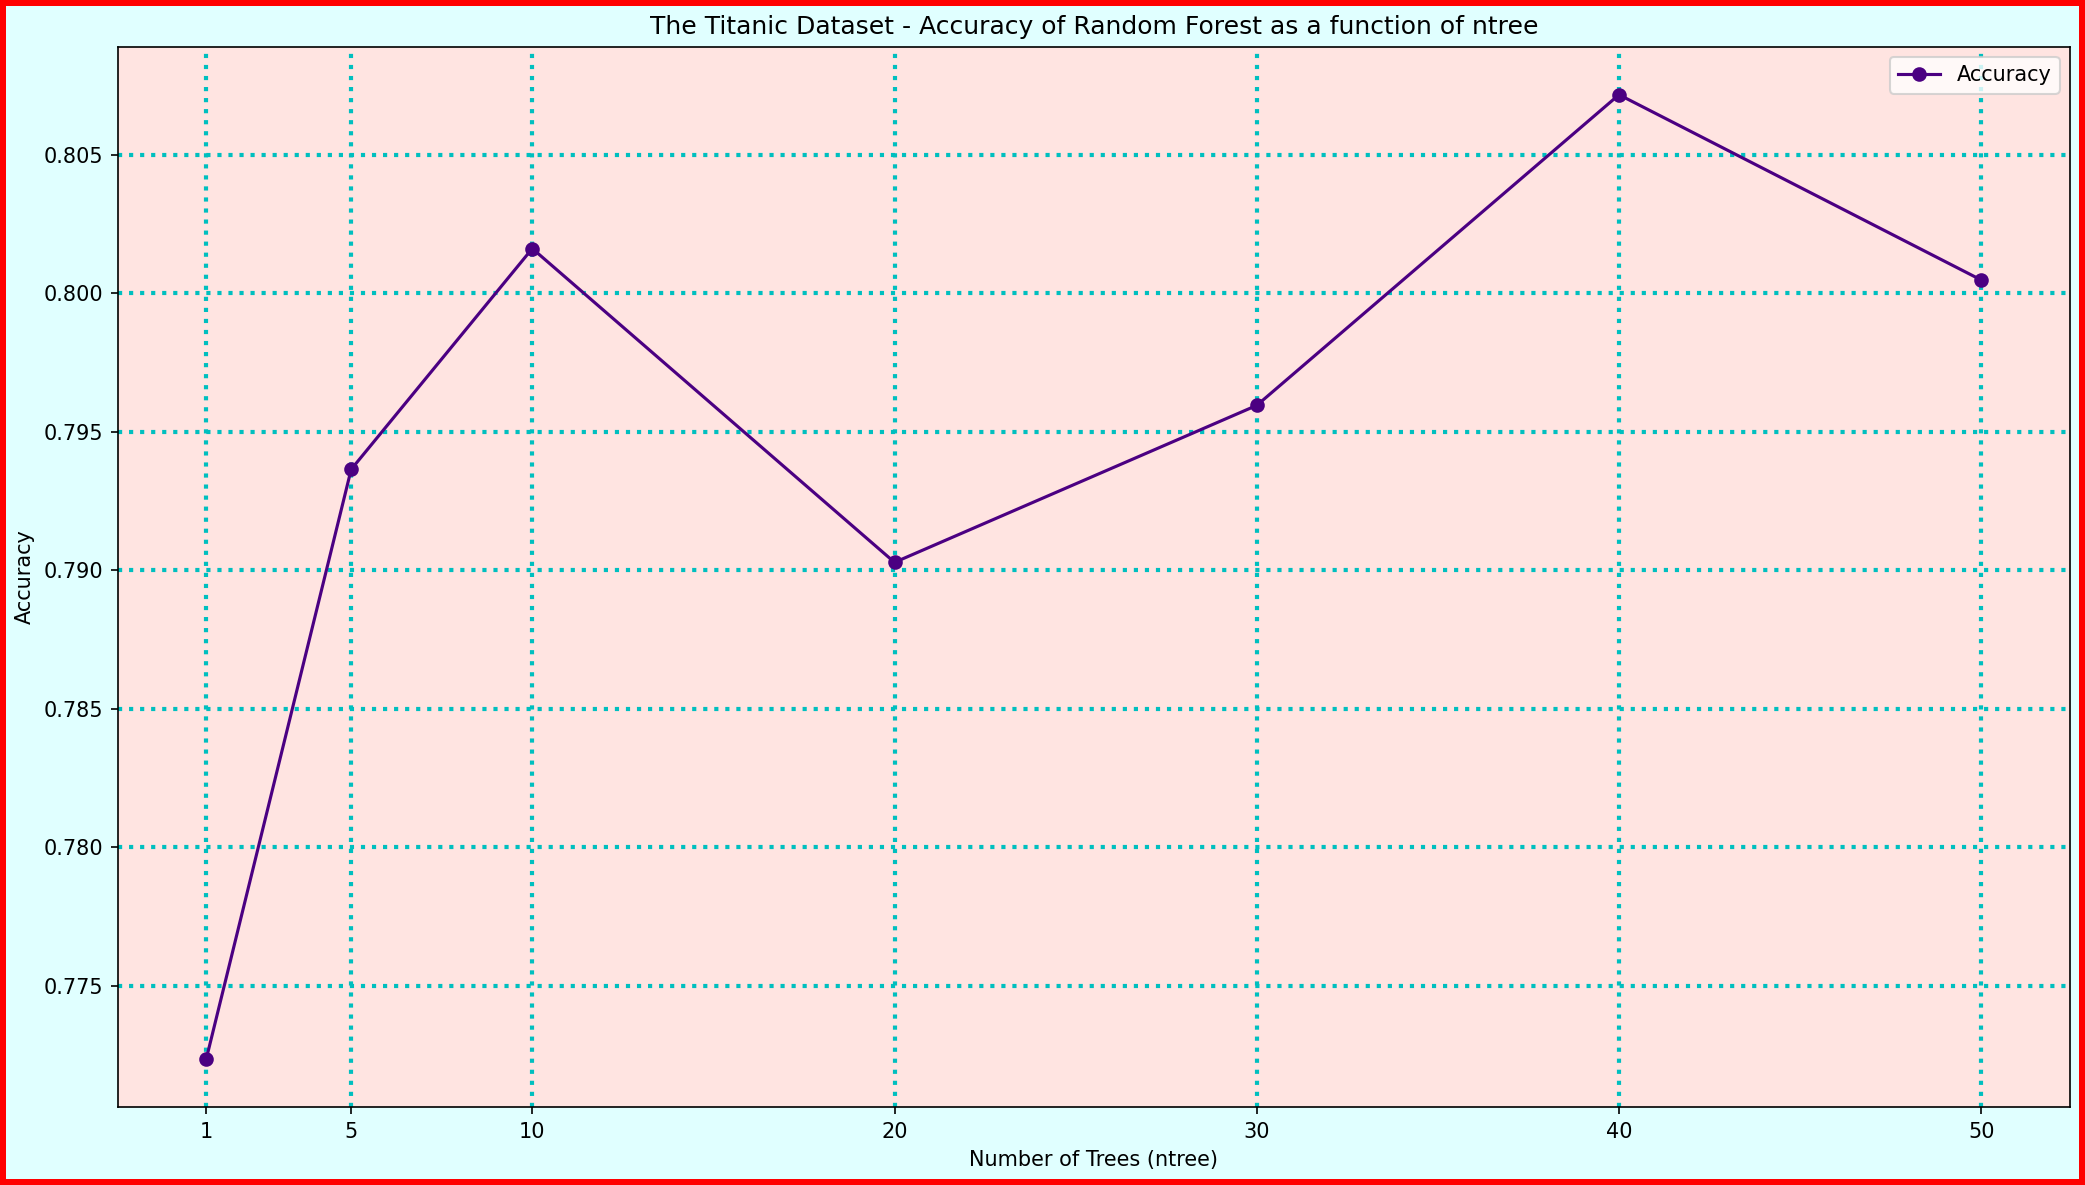

In [72]:
#### Plot 13 - Titanic Accuracy ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightcyan', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, titanic_accuracy, marker='o', color='indigo', label='Accuracy')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Accuracy')
plt.title('The Titanic Dataset - Accuracy of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('mistyrose')
plt.savefig('Titanic_Accuracy.pdf')
plt.show()

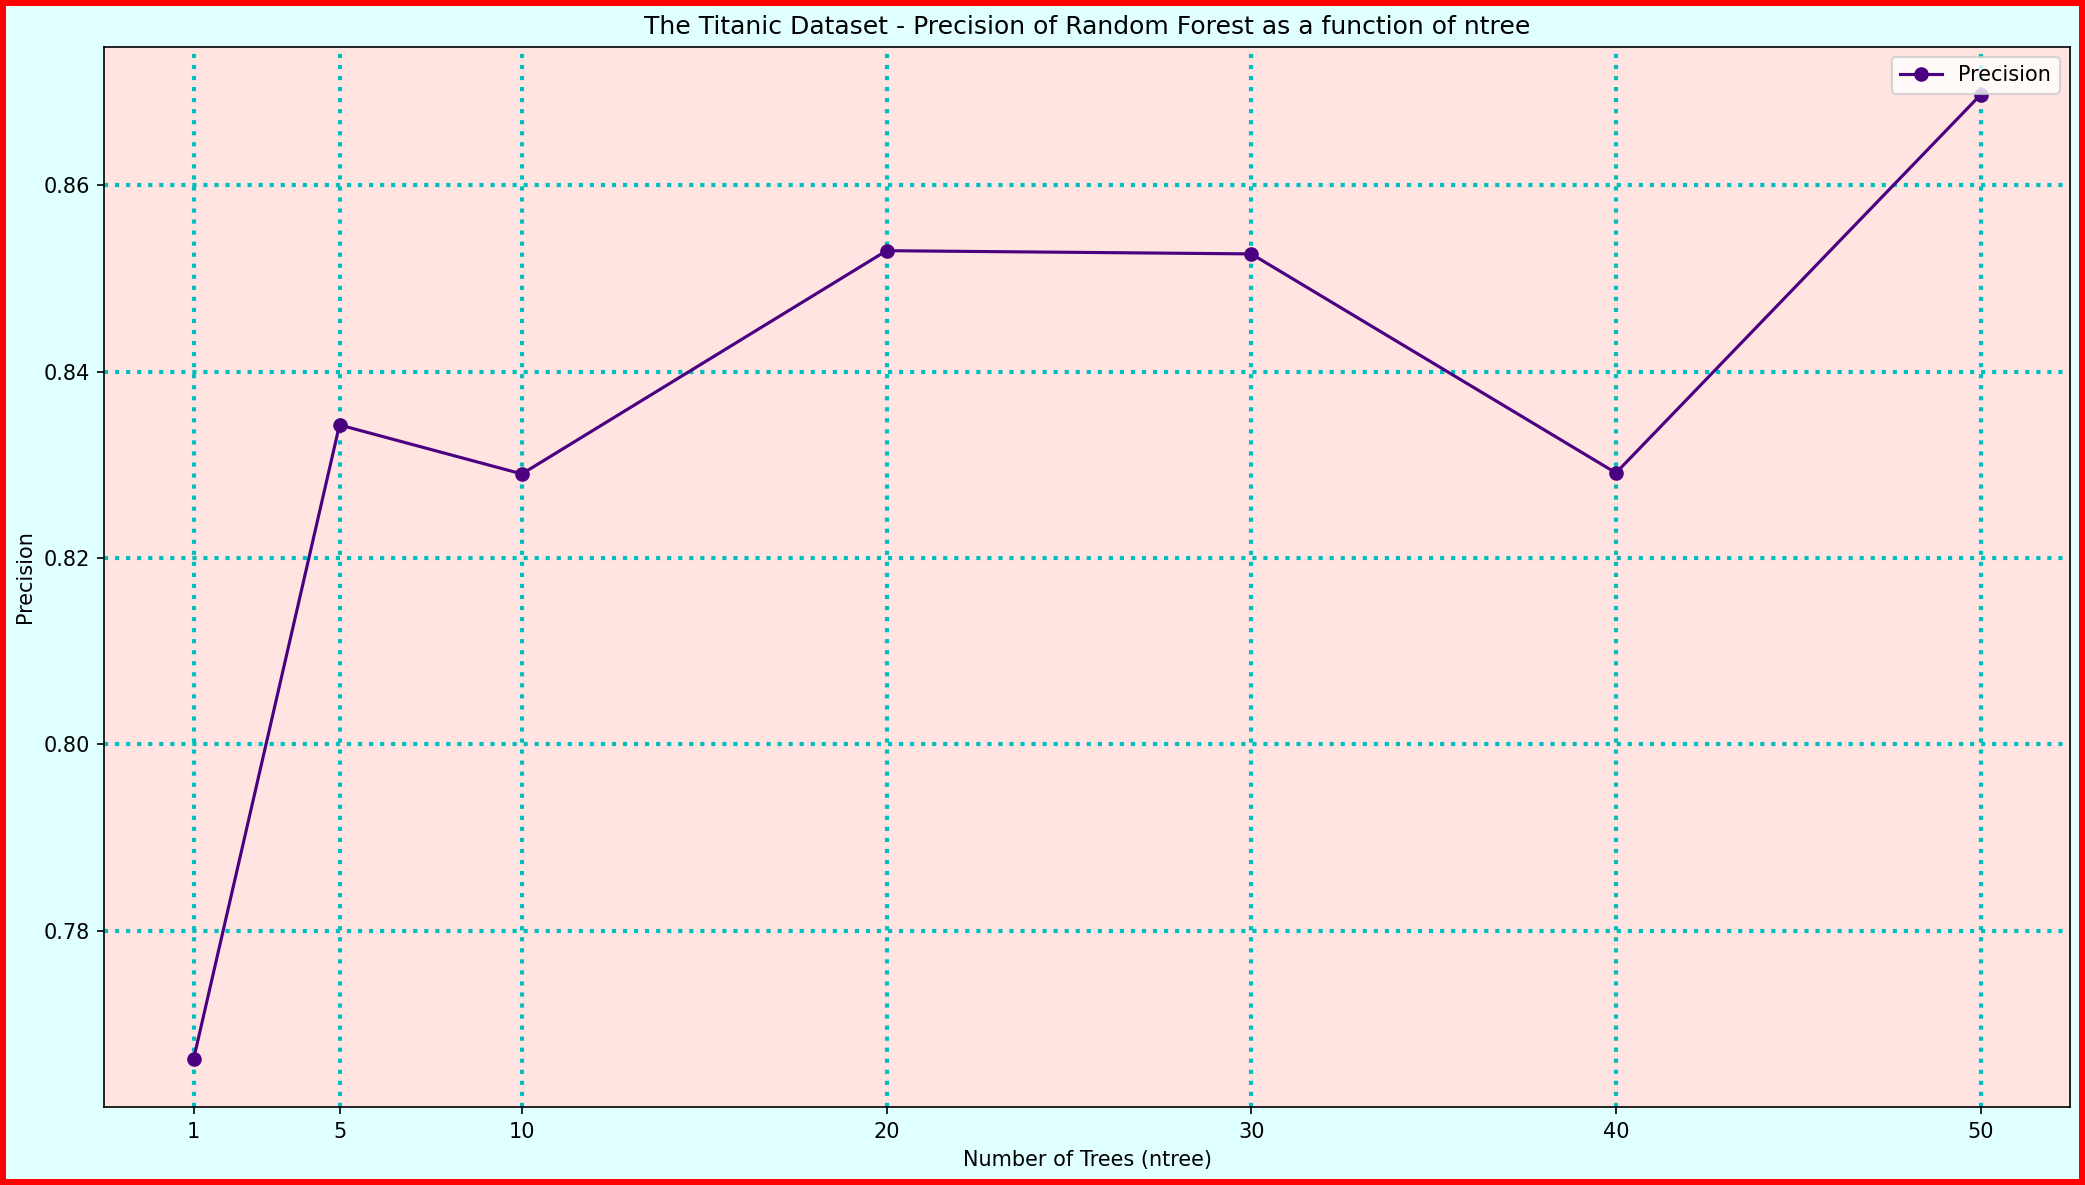

In [74]:
#### Plot 14 - Titanic Precision ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightcyan', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, titanic_precision, marker='o', color='indigo', label='Precision')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Precision')
plt.title('The Titanic Dataset - Precision of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('mistyrose')
plt.savefig('Titanic_Precision.pdf')
plt.show()

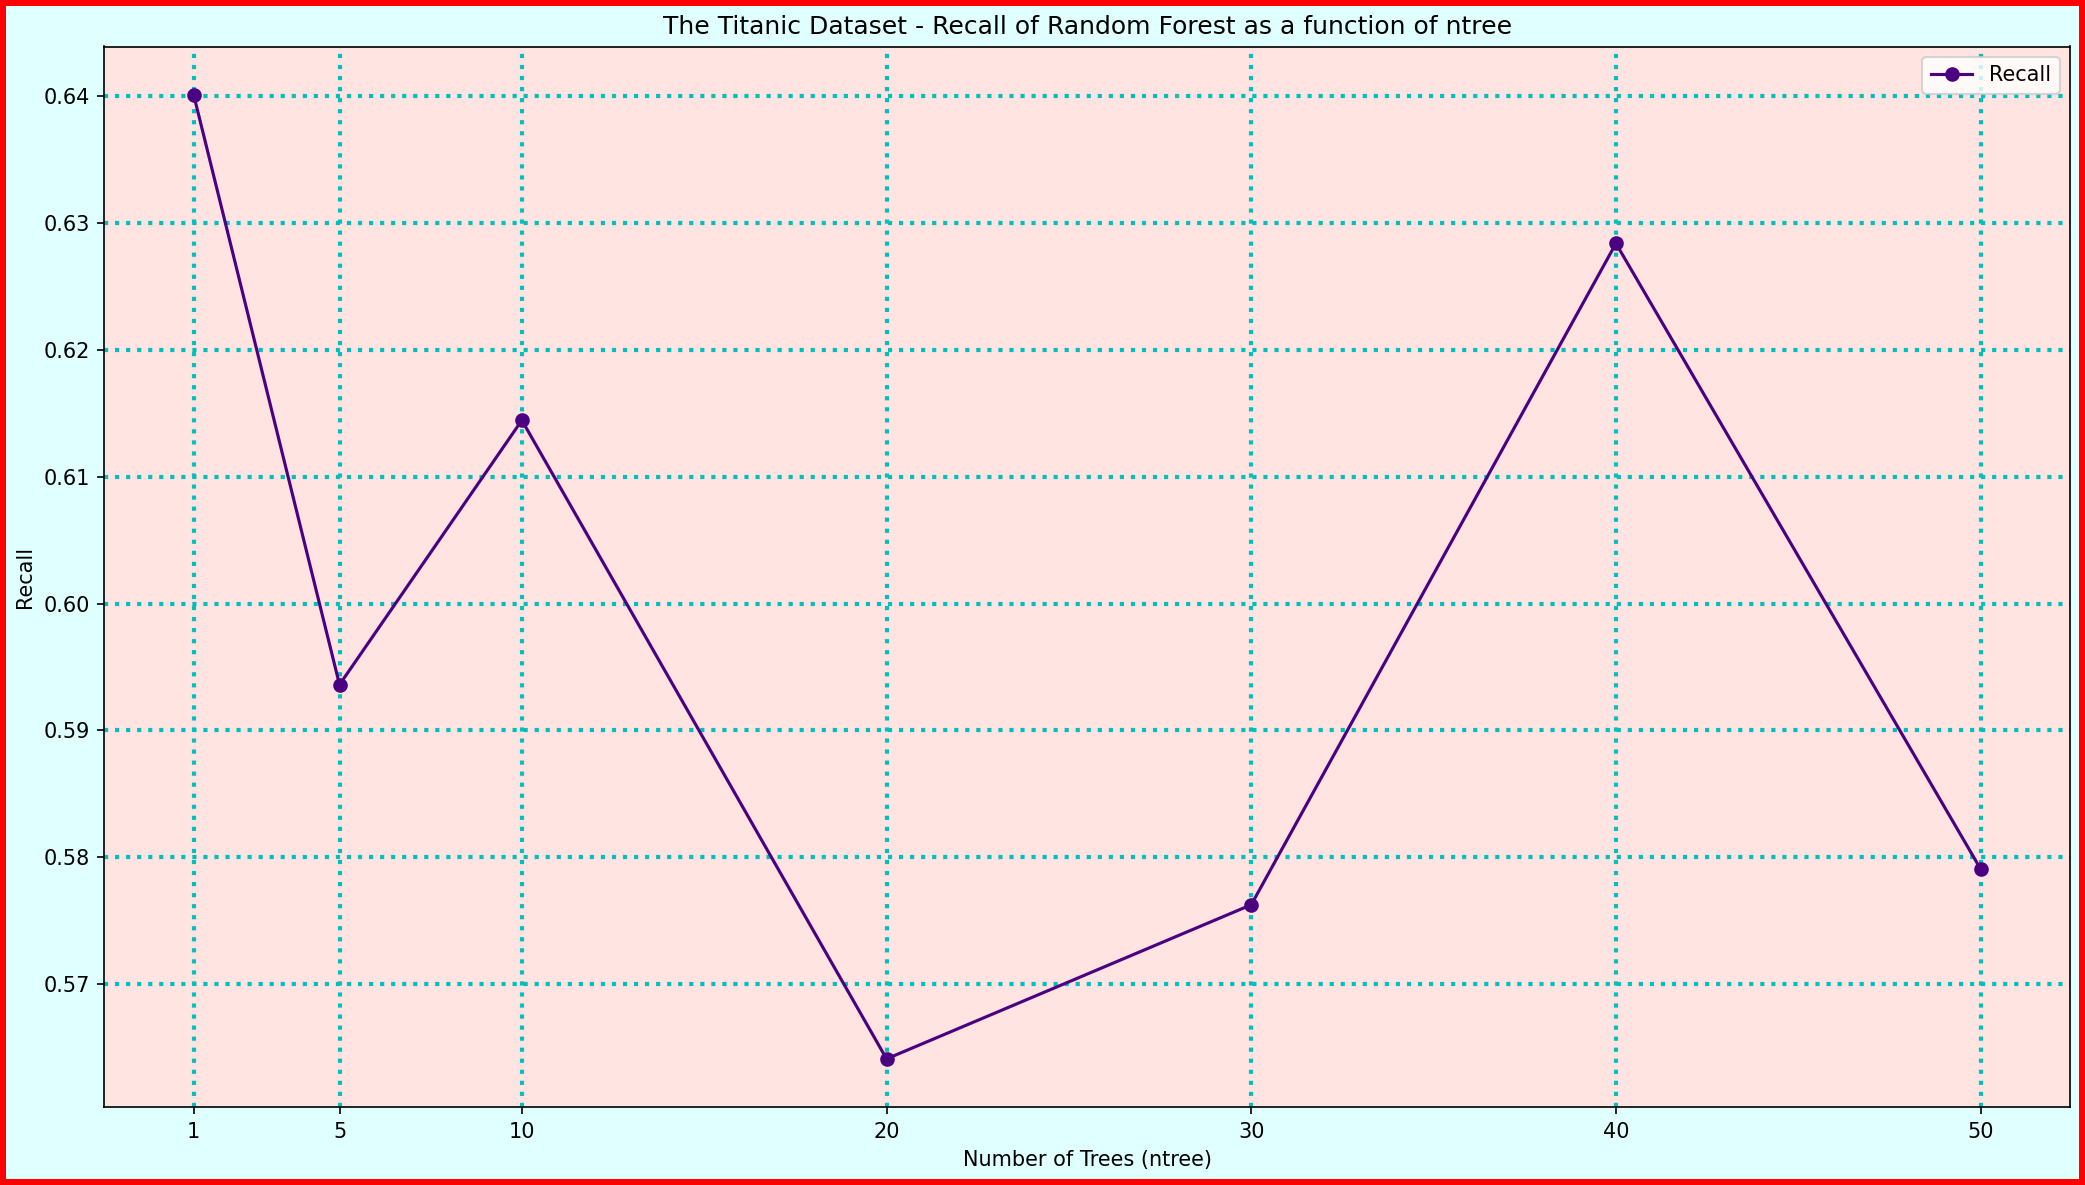

In [76]:
#### Plot 15 - Titanic Recall ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightcyan', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, titanic_recall, marker='o', color='indigo', label='Recall')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Recall')
plt.title('The Titanic Dataset - Recall of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('mistyrose')
plt.savefig('Titanic_Recall.pdf')
plt.show()

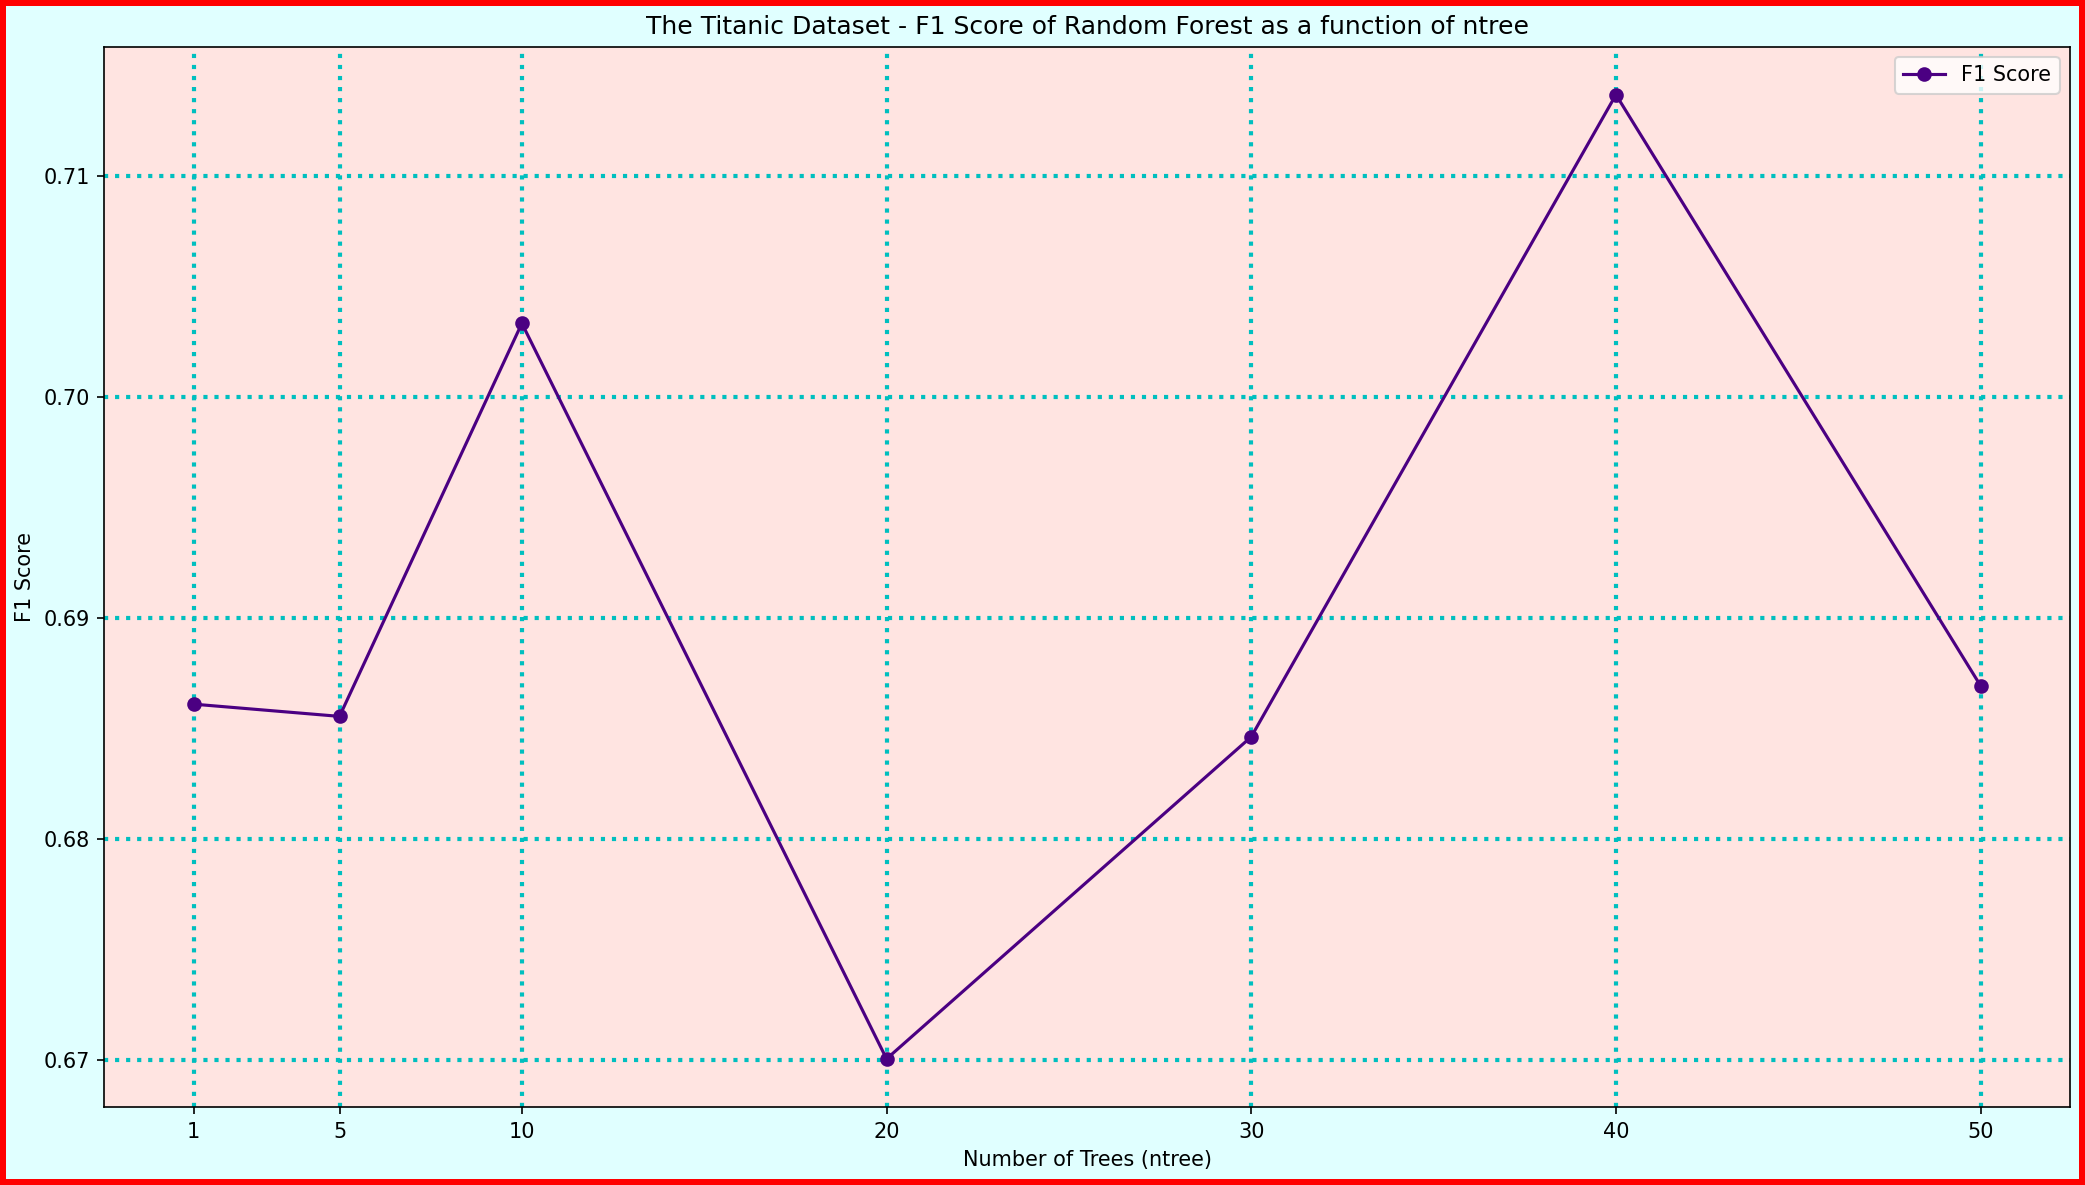

In [78]:
#### Plot 16 - Titanic F1 ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightcyan', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, titanic_f1, marker='o', color='indigo', label='F1 Score')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('F1 Score')
plt.title('The Titanic Dataset - F1 Score of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('mistyrose')
plt.savefig('Titanic_F1.pdf')
plt.show()